# 자율주행 보조 시스템 만들기
## RetinaNet 기반 Object Detection 프로젝트

### ☘️프로젝트 개요🕵️‍♀️

먼저 KITTI 도로 데이터를 살펴보니 한 이미지에 `여러 객체`가 있고, `작은 객체도 많았`다.
그래서 이미지와 Bounding Box를 학습용 형태로 바꾸고, 여러 크기의 Anchor를 이미지 전체에 깔았다.

각 Anchor가 실제 객체와 얼마나 겹치는지 `IoU로 비교해서 학습 정답을 만들었`다.

모델 쪽에서는 `ResNet50이 이미지 특징을 뽑고 FPN이 여러 크기의 특징을 함께 사용`했다.

`RetinaNet의 두 Head`가 각 Anchor마다 `‘무엇인지’`와 `‘어디인지`’를 예측하고, `Focal Loss와 Smooth L1 Loss`를 통해 틀린 만큼 가중치를 수정했다.

학습이 끝나면 Anchor 기준의 예측값을 `실제 Bounding Box로 Decode`하고 `NMS로 중복을 제거`했다.

마지막으로 `탐지된 객체의 종류·위치·크기를 이용`해 `GO/STOP을 판단하는 규칙`을 붙였다.

### 프로젝트 핵심 질문

1. KITTI 데이터셋은 어떤 클래스와 Bounding Box 특성을 가지는가?
2. 이러한 데이터 특성에 맞게 어떤 전처리와 Label Encoding이 필요한가?
3. RetinaNet은 KITTI 객체를 정상적으로 학습하고 탐지할 수 있는가?
4. 학습된 Object Detection 시스템을 자율주행 테스트 데이터에 적용했을 때
   90% 이상의 테스트 정확도를 달성할 수 있는가?

## 프로젝트 루브릭

### Rubric 1. KITTI 데이터 분석 및 가공

- KITTI 데이터셋의 구조와 annotation 형식을 확인한다.
- 클래스 분포를 분석한다.
- 객체 수와 Bounding Box의 크기 및 특성을 분석한다.
- 분석 결과를 바탕으로 Detection 학습에 필요한 데이터 가공을 수행한다.

### Rubric 2. RetinaNet 학습 및 Object Detection 시각화

- RetinaNet의 Backbone, FPN, Detection Head를 구성한다.
- Anchor와 Ground Truth를 잘~ 매칭한다.
- Focal Loss와 Bounding Box Regression Loss를 이용해 학습한다.
- Validation 데이터에서 Detection 결과를 Decode하고 NMS를 수행한다.
- 예측 Bounding Box가 표시된 이미지를 시각화한다.

### Rubric 3. 자율주행 테스트 시스템 정확도 90% 이상

- 별도의 테스트 이미지를 대상으로 Detection을 수행한다.
- 테스트별 기대 결과와 모델 판정 결과를 비교한다.
- 시스템 정확도를 정량적으로 계산한다.
- 정확도 90% 이상을 목표로 한다.
- 목표 미달 시 오류 사례를 분석하고 개선 실험을 수행한다.

## 현재 환경 체크

In [1]:
# ============================================================
# Step 0-1. 우와 코랩 프로 플러스에서 환경 체크!
# ============================================================

import sys
import torch
import torchvision

print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("TorchVision :", torchvision.__version__)
print("CUDA usable :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))

Python      : 3.13.15
PyTorch     : 2.11.0+cu128
TorchVision : 0.26.0+cu128
CUDA usable : True
GPU         : NVIDIA L4


In [2]:
# ============================================================
# Step 0-2. 구글 드라이브 경로 세팅.
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "2026.789_AI researcher"
)

PROJECT_ROOT = ROOT

DATA_DIR = (
    ROOT
    / "data"
    / "object_detection"
    / "project"
)

MODEL_DIR = (
    ROOT
    / "models"
    / "object_detection"
    / "project"
)

CHECKPOINT_DIR = (
    MODEL_DIR
    / "checkpoints"
)

OUTPUT_DIR = (
    ROOT
    / "outputs"
    / "object_detection"
    / "project"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

METRIC_DIR = (
    OUTPUT_DIR
    / "metrics"
)

PREDICTION_DIR = (
    OUTPUT_DIR
    / "predictions"
)

for path in [
    DATA_DIR,
    MODEL_DIR,
    CHECKPOINT_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    METRIC_DIR,
    PREDICTION_DIR,
]:
    path.mkdir(
        parents=True,
        exist_ok=True
    )

print("ROOT           :", ROOT)
print("DATA_DIR       :", DATA_DIR)
print("CHECKPOINT_DIR :", CHECKPOINT_DIR)
print("OUTPUT_DIR     :", OUTPUT_DIR)

Mounted at /content/drive
ROOT           : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher
DATA_DIR       : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/object_detection/project
CHECKPOINT_DIR : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/object_detection/project/checkpoints
OUTPUT_DIR     : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/object_detection/project


### KITTI는 런타임 캐시를 따로 유지해서 매번 드라이브에서 읽을 필요 없도록 세팅함

In [3]:
# ============================================================
# Step 0-3. 런타임 데이터셋 캐싱
# ============================================================

KITTI_DATA_PATH = Path(
    "/content/aiffel_data/object_detection"
)

KITTI_DATA_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "KITTI runtime path:",
    KITTI_DATA_PATH
)

KITTI runtime path: /content/aiffel_data/object_detection


In [4]:
TEST_SYSTEM_DIR = DATA_DIR / "test_system"
GO_STOP_DIR = TEST_SYSTEM_DIR / "go_stop"
REFERENCE_DIR = TEST_SYSTEM_DIR / "reference"

for path in [
    TEST_SYSTEM_DIR,
    GO_STOP_DIR,
    REFERENCE_DIR,
]:
    path.mkdir(
        parents=True,
        exist_ok=True
    )

print("GO/STOP test :", GO_STOP_DIR)
print("Reference    :", REFERENCE_DIR)

GO/STOP test : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/object_detection/project/test_system/go_stop
Reference    : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/object_detection/project/test_system/reference


In [5]:
go_images = sorted(GO_STOP_DIR.glob("go_*.png"))
stop_images = sorted(GO_STOP_DIR.glob("stop_*.png"))

print("GO   :", len(go_images), [p.name for p in go_images])
print("STOP :", len(stop_images), [p.name for p in stop_images])

assert len(go_images) == 5
assert len(stop_images) == 5

print("\nGO/STOP 테스트 데이터 10장 준비 완료")

GO   : 5 ['go_1.png', 'go_2.png', 'go_3.png', 'go_4.png', 'go_5.png']
STOP : 5 ['stop_1.png', 'stop_2.png', 'stop_3.png', 'stop_4.png', 'stop_5.png']

GO/STOP 테스트 데이터 10장 준비 완료


## KITTI EDA

In [6]:
# ============================================================
# Step 1-1. 학습데이터 로드
# ============================================================

import torchvision
from pathlib import Path

kitti_train = torchvision.datasets.Kitti(
    root=str(KITTI_DATA_PATH),
    train=True,
    download=True,
)

print("KITTI train images :", len(kitti_train))

100%|██████████| 12.6G/12.6G [09:05<00:00, 23.0MB/s]
100%|██████████| 5.60M/5.60M [00:01<00:00, 5.49MB/s]


KITTI train images : 7481


In [7]:
image_dir = (
    KITTI_DATA_PATH
    / "Kitti"
    / "raw"
    / "training"
    / "image_2"
)

label_dir = (
    KITTI_DATA_PATH
    / "Kitti"
    / "raw"
    / "training"
    / "label_2"
)

print("image_dir exists:", image_dir.exists())
print("label_dir exists:", label_dir.exists())

image_dir exists: True
label_dir exists: True


In [8]:
# ============================================================
# Step 1-3. 토치비전이 반환하는 샘플 구조 체크
# ============================================================

image, target = kitti_train[0]

print("Image type :", type(image))
print("Image size :", image.size)
print("Target type:", type(target))
print("Objects    :", len(target))

print("\nFirst object annotation")
print(target[0])

Image type : <class 'PIL.PngImagePlugin.PngImageFile'>
Image size : (1242, 375)
Target type: <class 'list'>
Objects    : 5

First object annotation
{'type': 'Car', 'truncated': 0.0, 'occluded': 0, 'alpha': -1.58, 'bbox': [584.05, 179.71, 619.83, 208.08], 'dimensions': [1.26, 1.6, 3.56], 'location': [-0.43, 1.59, 34.2], 'rotation_y': -1.59}


In [9]:
print("\nAnnotation fields")
print(target[0].keys())


Annotation fields
dict_keys(['type', 'truncated', 'occluded', 'alpha', 'bbox', 'dimensions', 'location', 'rotation_y'])


### KITTI Annotation 구조 해석

KITTI annotation에는 2D Bounding Box 외에도
3차원 객체 정보를 포함한 다양한 annotation이 존재한다.

본 프로젝트의 RetinaNet은 2D Object Detection을 수행하므로
주요 학습 정보로 다음을 사용한다.

- `type`: 객체 클래스
- `bbox`: `[xmin, ymin, xmax, ymax]` 형식의 2D Bounding Box

다음 정보는 데이터 특성 분석에는 활용할 수 있지만
현재 RetinaNet의 직접적인 학습 target으로 사용하지 않는다.

- `truncated`
- `occluded`
- `alpha`
- `dimensions`
- `location`
- `rotation_y`

따라서 데이터 가공 단계에서는
2D Bounding Box와 클래스 정보를 중심으로 학습용 target을 구성하고자 함.

In [10]:
# ============================================================
# Step 1-4. 전체 클래스 분포를 DF로 만들기
# ============================================================

import pandas as pd
import numpy as np

records = []

for image_id in range(len(kitti_train)):

    image, target = kitti_train[image_id]

    image_width, image_height = image.size

    for obj in target:

        x1, y1, x2, y2 = obj["bbox"]

        bbox_width = x2 - x1
        bbox_height = y2 - y1
        bbox_area = bbox_width * bbox_height

        image_area = (
            image_width
            * image_height
        )

        records.append(
            {
                "image_id": image_id,

                "class_name":
                    obj["type"],

                "image_width":
                    image_width,

                "image_height":
                    image_height,

                "bbox_x1":
                    x1,

                "bbox_y1":
                    y1,

                "bbox_x2":
                    x2,

                "bbox_y2":
                    y2,

                "bbox_width":
                    bbox_width,

                "bbox_height":
                    bbox_height,

                "bbox_area":
                    bbox_area,

                "bbox_area_ratio":
                    bbox_area / image_area,

                "truncated":
                    obj["truncated"],

                "occluded":
                    obj["occluded"],
            }
        )


eda_df = pd.DataFrame(records)

print("annotations :", len(eda_df))
print("images      :", eda_df["image_id"].nunique())

display(eda_df.head())

annotations : 51865
images      : 7481


,image_id,class_name,image_width,image_height,bbox_x1,bbox_y1,bbox_x2,bbox_y2,bbox_width,bbox_height,bbox_area,bbox_area_ratio,truncated,occluded
0,0,Car,1242,375,584.05,179.71,619.83,208.08,35.78,28.37,1015.0786,0.002179,0.0,0
1,0,Car,1242,375,537.40,179.80,570.76,205.36,33.36,25.56,852.6816,0.001831,0.0,0
2,0,Van,1242,375,608.10,166.89,627.75,193.81,19.65,26.92,528.9780,0.001136,0.0,2
3,0,DontCare,1242,375,490.81,171.90,533.56,189.65,42.75,17.75,758.8125,0.001629,-1.0,-1
4,0,DontCare,1242,375,691.85,173.98,714.81,187.56,22.96,13.58,311.7968,0.000669,-1.0,-1


In [11]:
# ============================================================
# Step 1-5. 클래스별 Annotation 분포 확인
# ============================================================

class_counts = (
    eda_df["class_name"]
    .value_counts()
)

print(class_counts)

class_name
Car               28742
DontCare          11295
Pedestrian         4487
Van                2914
Cyclist            1627
Truck              1094
Misc                973
Tram                511
Person_sitting      222
Name: count, dtype: int64


In [13]:
class_distribution = pd.DataFrame(
    {
        "count": class_counts,
        "ratio":
            class_counts
            / len(eda_df),
    }
)

class_distribution["ratio_percent"] = (
    class_distribution["ratio"]
    * 100
)

display(class_distribution)

,count,ratio,ratio_percent
class_name,,,
Car,28742,0.554169,55.416948
DontCare,11295,0.217777,21.777692
Pedestrian,4487,0.086513,8.651306
Van,2914,0.056184,5.618432
Cyclist,1627,0.031370,3.136990
Truck,1094,0.021093,2.109322
Misc,973,0.018760,1.876024
Tram,511,0.009853,0.985250
Person_sitting,222,0.004280,0.428034


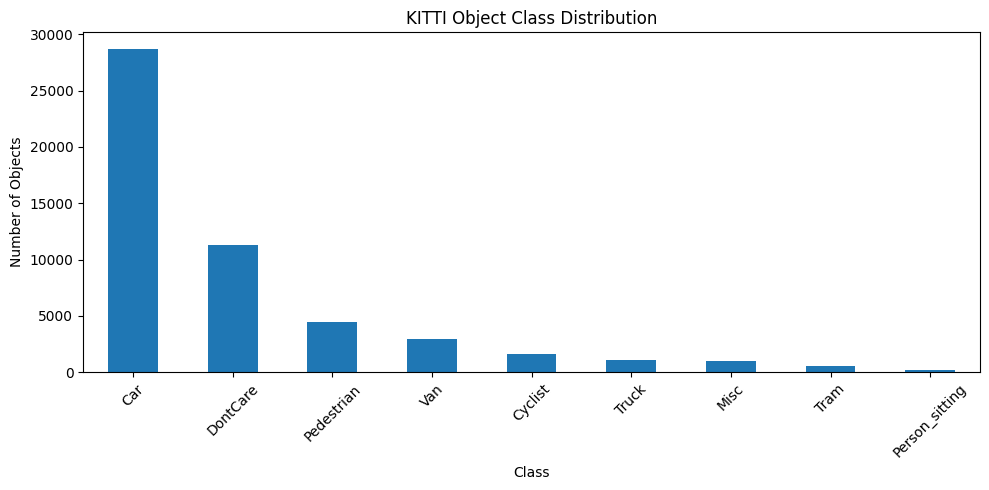

In [14]:
# ============================================================
# Step 1-6. 클래스 분포 시각화
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

class_counts.plot(
    kind="bar"
)

plt.title(
    "KITTI Object Class Distribution"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Number of Objects"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

### EDA 1. KITTI 데이터 구조 및 클래스 분포 분석

KITTI training split은 총 7,481개의 이미지로 구성되어 있으며,
전체 annotation은 51,865개이다.

annotation은 `type`, `bbox`뿐 아니라
`truncated`, `occluded`, `dimensions`, `location`, `rotation_y` 등의
3차원 및 가림 정보가 있다.

본 프로젝트는 RetinaNet 기반 2D Object Detection을 수행하므로
주요 학습 target으로 객체 클래스(`type`)와
2D Bounding Box(`bbox`)를 사용한다.

전체 annotation 가운데 `DontCare`는 11,295개(21.78%)로 나타났다.
`DontCare`를 제외하면 실제 학습 대상 8개 클래스 annotation은
40,570개이다.

특히 Car가 전체 annotation의 55.42%,
학습 대상 annotation의 약 70.85%를 차지해
클래스 분포가 크게 불균형한 것을 확인했다.

따라서 이후 데이터 가공에서는
`DontCare`를 학습 클래스에서 제외하고
8개 탐지 클래스를 명시적으로 매핑한다.

또한 Anchor 기반 one-stage detector에서는 객체 클래스 간 불균형뿐 아니라
대량의 background Anchor가 발생하므로,
RetinaNet의 Focal Loss를 이용해 쉬운 negative sample의 영향을 줄인다.

In [15]:
# ============================================================
# Step 1-7. 이미지 당 객체 수 분석
# ============================================================

TARGET_CLASSES = [
    "Car",
    "Van",
    "Truck",
    "Pedestrian",
    "Person_sitting",
    "Cyclist",
    "Tram",
    "Misc",
]

target_df = (
    eda_df[
        eda_df["class_name"].isin(TARGET_CLASSES)
    ]
    .copy()
)

print("전체 annotation :", len(eda_df))
print("학습 대상       :", len(target_df))
print("제외 DontCare   :", len(eda_df) - len(target_df))

전체 annotation : 51865
학습 대상       : 40570
제외 DontCare   : 11295


In [16]:
objects_per_image = (
    target_df
    .groupby("image_id")
    .size()
    .reindex(
        range(len(kitti_train)),
        fill_value=0
    )
)

print(
    objects_per_image.describe()
)

print(
    "\n객체가 없는 이미지:",
    int((objects_per_image == 0).sum())
)

print(
    "최대 객체 수:",
    int(objects_per_image.max())
)

count    7481.000000
mean        5.423072
std         3.738047
min         1.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        22.000000
dtype: float64

객체가 없는 이미지: 0
최대 객체 수: 22


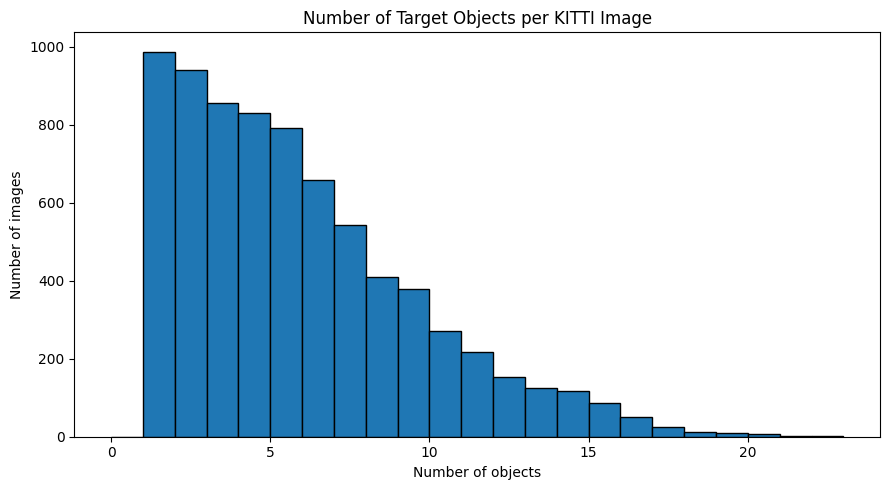

In [17]:
# 분포 확인
plt.figure(figsize=(9, 5))

plt.hist(
    objects_per_image,
    bins=range(
        0,
        int(objects_per_image.max()) + 2
    ),
    edgecolor="black",
)

plt.title(
    "Number of Target Objects per KITTI Image"
)

plt.xlabel(
    "Number of objects"
)

plt.ylabel(
    "Number of images"
)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# Step 1-8. 바운딩박스 크기 분석
# ============================================================

bbox_stats = (
    target_df[
        [
            "bbox_width",
            "bbox_height",
            "bbox_area",
            "bbox_area_ratio",
        ]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
)

display(bbox_stats)

,bbox_width,bbox_height,bbox_area,bbox_area_ratio
count,40570.000000,40570.000000,40570.000000,40570.000000
mean,101.527631,73.391805,11105.084639,0.023889
std,88.528279,57.328950,18775.843646,0.040362
min,0.110000,12.670000,1.487200,0.000003
1%,11.710000,15.880000,285.740976,0.000614
5%,20.520000,20.284500,525.267530,0.001131
25%,39.700000,33.170000,1417.392000,0.003050
50%,68.930000,52.440000,3564.392900,0.007667
75%,131.655000,93.977500,11280.399825,0.024343
95%,300.769500,188.004000,51830.426170,0.112513


In [19]:
area_ratio_percent = (
    target_df["bbox_area_ratio"]
    * 100
)

print(
    "Bounding Box Area Ratio (%)"
)

print(
    area_ratio_percent.describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
)

Bounding Box Area Ratio (%)
count    40570.000000
mean         2.388937
std          4.036177
min          0.000328
1%           0.061351
5%           0.113117
25%          0.304955
50%          0.766715
75%          2.434279
95%         11.251255
99%         18.096178
max         40.946074
Name: bbox_area_ratio, dtype: float64


In [20]:
# ============================================================
# Step 1-9. 클래스별 Bounding Box 크기 비교
# ============================================================

class_bbox_stats = (
    target_df
    .groupby("class_name")
    .agg(
        count=(
            "class_name",
            "size"
        ),

        median_width=(
            "bbox_width",
            "median"
        ),

        median_height=(
            "bbox_height",
            "median"
        ),

        median_area_ratio=(
            "bbox_area_ratio",
            "median"
        ),
    )
    .sort_values(
        "count",
        ascending=False
    )
)

class_bbox_stats[
    "median_area_percent"
] = (
    class_bbox_stats[
        "median_area_ratio"
    ]
    * 100
)

display(
    class_bbox_stats[
        [
            "count",
            "median_width",
            "median_height",
            "median_area_percent",
        ]
    ]
)

,count,median_width,median_height,median_area_percent
class_name,,,,
Car,28742,79.700,46.990,0.796766
Pedestrian,4487,33.330,87.890,0.636129
Van,2914,75.720,52.980,0.858948
Cyclist,1627,37.940,60.050,0.517647
Truck,1094,60.905,59.295,0.774457
Misc,973,61.790,51.260,0.686693
Tram,511,96.410,72.220,1.689259
Person_sitting,222,69.660,100.120,1.428434


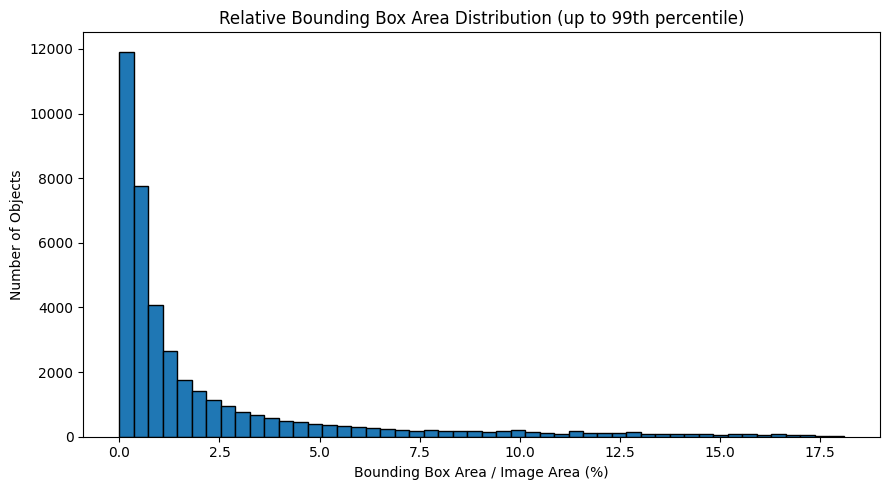

In [21]:
# ============================================================
# Step 1-10. Bbox 상대 크기 분포 시각화
# ============================================================

area_percent = (
    target_df["bbox_area_ratio"]
    * 100
)

upper = (
    area_percent.quantile(0.99)
)

plt.figure(figsize=(9, 5))

plt.hist(
    area_percent[
        area_percent <= upper
    ],
    bins=50,
    edgecolor="black",
)

plt.title(
    "Relative Bounding Box Area Distribution "
    "(up to 99th percentile)"
)

plt.xlabel(
    "Bounding Box Area / Image Area (%)"
)

plt.ylabel(
    "Number of Objects"
)

plt.tight_layout()
plt.show()

### EDA 결과 해석

KITTI training dataset의 7,481개 이미지를 분석한 결과,
`DontCare`를 제외한 학습 대상 annotation은 총 40,570개였다.

이미지 한 장에는 평균 5.42개, 중앙값 5개의 객체가 존재했으며
`최대 22개의 객체!!`가 포함된 이미지도 확인됐다.
따라서 본 데이터셋은 단일 객체 분류가 아니라
한 이미지에서 여러 객체의 위치와 클래스를 동시에 추정해야 하는
Object Detection인 것.

Bounding Box의 상대 면적을 분석한 결과,
중앙값은 전체 이미지 면적의 약 0.77%에 불과했다.
또한 전체 객체의 75%가 이미지 면적의 약 2.43% 이하를 차지했다.
이는 KITTI 도로 영상에 작은 객체가 다수 존재한다는 것을 의미한다.

클래스별 중앙 Bounding Box 면적도
Car 0.80%, Pedestrian 0.64%, Cyclist 0.52% 등으로 작게 나타났으며,
객체 클래스에 따라 크기와 종횡비에도 차이가 존재한다.

따라서 본 프로젝트에서는 다음과 같은 데이터 가공 및 모델 구조를 사용한다.

- `DontCare` annotation은 학습 대상에서 제외한다.
- 8개의 객체 클래스를 정수 class id로 변환한다.
- 서로 다른 이미지 크기를 RetinaNet 입력에 맞게 resize 및 padding한다.
- 여러 크기와 aspect ratio의 Anchor를 생성한다.
- 다양한 크기의 객체를 처리하기 위해 FPN의 P3~P7 feature level을 사용한다.
- Anchor 기반 one-stage detector에서 발생하는 foreground/background 불균형을
  완화하기 위해 Focal Loss를 사용한다.

## Annotation 품질 확인해보기

EDA 결과에 하나 눈에 띄는 값이 있음.

- bbox_width min = 0.11 px
- bbox_area min  = 1.4872 px²

아주 작은 annotation이 있음...

멀리 있는 객체나 잘린 객체일 수 있기 때문.

그래서 임의로 삭제하기 전에 truncated / occluded와 bbox validity를 확인하고자 함.

In [22]:
# ============================================================
# Step 1-11. 바운딩박스 유효성 검사
# ============================================================

invalid_bbox = target_df[
    (target_df["bbox_width"] <= 0)
    | (target_df["bbox_height"] <= 0)
]

print("Invalid bbox count :", len(invalid_bbox))

tiny_bbox = target_df[
    target_df["bbox_area_ratio"] < 0.001
]

print(
    "Very small bbox (< 0.1% image area):",
    len(tiny_bbox)
)

print(
    "Very small bbox ratio:",
    len(tiny_bbox) / len(target_df)
)

display(
    tiny_bbox[
        [
            "image_id",
            "class_name",
            "bbox_width",
            "bbox_height",
            "bbox_area_ratio",
            "truncated",
            "occluded",
        ]
    ].head(10)
)

Invalid bbox count : 0
Very small bbox (< 0.1% image area): 1503
Very small bbox ratio: 0.037047079122504316


,image_id,class_name,bbox_width,bbox_height,bbox_area_ratio,truncated,occluded
20,3,Car,24.56,15.85,0.000836,0.0,0
75,11,Pedestrian,9.67,31.11,0.000646,0.0,1
238,39,Car,19.53,17.56,0.000736,0.0,0
272,45,Pedestrian,11.00,35.69,0.000843,0.0,0
280,46,Pedestrian,8.00,43.07,0.000740,0.0,2
288,49,Car,17.24,13.56,0.000502,0.0,0
383,66,Car,20.69,14.17,0.000629,0.0,0
384,66,Car,24.05,14.47,0.000747,0.0,0
388,67,Car,17.90,14.19,0.000545,0.0,0
442,75,Car,23.98,19.09,0.000983,0.0,0


In [23]:
# ============================================================
# Step 1-12. 가리거나 잘려있는 상태 분석
# ============================================================

print("Occlusion distribution")
print(
    target_df["occluded"]
    .value_counts()
    .sort_index()
)

print("\nTruncation statistics")
print(
    target_df["truncated"]
    .describe()
)

print(
    "\nTruncated > 0:",
    int(
        (target_df["truncated"] > 0)
        .sum()
    )
)

print(
    "Truncated > 0 ratio:",
    (
        target_df["truncated"] > 0
    ).mean()
)

Occlusion distribution
occluded
0    19181
1    11090
2     8101
3     2198
Name: count, dtype: int64

Truncation statistics
count    40570.000000
mean         0.073896
std          0.223002
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: truncated, dtype: float64

Truncated > 0: 5391
Truncated > 0 ratio: 0.13288143948730588


## 돈케어 제거하는 것을 시작으로 학습용 데이터 가공하기

In [24]:
# ============================================================
# Step 2-1. 클래스 매칭
# ============================================================

CLASS_NAMES = [
    "Car",
    "Van",
    "Truck",
    "Pedestrian",
    "Person_sitting",
    "Cyclist",
    "Tram",
    "Misc",
]

CLASS_TO_ID = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

ID_TO_CLASS = {
    idx: name
    for name, idx in CLASS_TO_ID.items()
}

NUM_CLASSES = len(CLASS_NAMES)

print("Number of classes:", NUM_CLASSES)
print(CLASS_TO_ID)

Number of classes: 8
{'Car': 0, 'Van': 1, 'Truck': 2, 'Pedestrian': 3, 'Person_sitting': 4, 'Cyclist': 5, 'Tram': 6, 'Misc': 7}


### Detection Target 가공

TorchVision KITTI annotation에는 `DontCare`를 포함한 여러 annotation이 존재한다.

RetinaNet 학습에서는 실제 탐지 대상 8개 클래스만 사용하고,
각 객체의 `bbox`를 `[xmin, ymin, xmax, ymax]` 형태의 Tensor로 변환한다.

`DontCare`는 객체 클래스를 의미하는 학습 target이 아니므로
classification target에서는 제외한다.

In [25]:
# ============================================================
# Step 2-2. KITTI Target 데이터 제공 준비
# ============================================================

import torch


def parse_kitti_target(target):

    boxes = []
    class_ids = []

    for obj in target:

        class_name = obj["type"]

        if class_name not in CLASS_TO_ID:
            continue

        boxes.append(
            obj["bbox"]
        )

        class_ids.append(
            CLASS_TO_ID[class_name]
        )

    boxes = torch.tensor(
        boxes,
        dtype=torch.float32
    ).reshape(-1, 4)

    class_ids = torch.tensor(
        class_ids,
        dtype=torch.long
    )

    return boxes, class_ids

In [26]:
# 검증
sample_image, sample_target = kitti_train[0]

sample_boxes, sample_classes = (
    parse_kitti_target(sample_target)
)

print(
    "Raw annotations :",
    len(sample_target)
)

print(
    "Training objects:",
    len(sample_boxes)
)

print(
    "boxes shape     :",
    sample_boxes.shape
)

print(
    "class ids       :",
    sample_classes.tolist()
)

print(
    "class names     :",
    [
        ID_TO_CLASS[int(c)]
        for c in sample_classes
    ]
)

Raw annotations : 5
Training objects: 3
boxes shape     : torch.Size([3, 4])
class ids       : [0, 0, 1]
class names     : ['Car', 'Car', 'Van']


### KITTI EDA 최종 결론 및 데이터 가공 방침

KITTI training 데이터의 40,570개 학습 대상 annotation을 분석한 결과,
Bounding Box 좌표가 잘못된 annotation은 발견되지 않았다.

전체 객체 중 이미지 면적의 0.1% 미만을 차지하는 매우 작은 객체가
1,503개(약 3.70%) 존재하였다.
또한 객체의 약 52.7%는 일정 수준 이상의 occlusion을 포함하고 있으며,
약 13.29%의 객체는 이미지 경계에서 일부 잘린(truncated) 상태였다.

이는 KITTI가 단순하고 명확한 객체만 포함하는 데이터가 아니라,
원거리의 작은 객체, 가려진 객체, 화면 일부에 걸친 객체를 함께 포함하는
실제 도로 환경에 가까운 Object Detection 데이터임을 보여준다.

따라서 본 프로젝트에서는 작은 객체와 occluded/truncated 객체를
임의로 제거하지 않고 학습 데이터에 유지한다.

최종 데이터 가공 방침은 다음과 같다.

1. `DontCare` annotation만 탐지 class target에서 제외한다.
2. 나머지 8개 클래스를 정수 class id로 변환한다.
3. 모든 유효 Bounding Box는 크기와 occlusion 여부에 관계없이 유지한다.
4. 학습 이미지에는 horizontal flip과 scale augmentation을 적용한다.
5. 이미지 비율을 유지하면서 resize한 후 FPN 입력에 맞게 padding한다.
6. Bounding Box를 RetinaNet Anchor regression에 필요한
   `(cx, cy, width, height)` 형태로 변환한다.
7. 다양한 크기의 객체를 탐지하기 위해 FPN P3~P7 및
   multi-scale / multi-aspect-ratio Anchor를 사용한다.

In [27]:
# ============================================================
# Step 2-3. Random Horizontal Flip - 바운딩 박스와 이미지 반드시 같이 변환!!
# ============================================================

import torchvision.transforms.functional as TF


def random_flip_horizontal(
    image,
    boxes,
    probability=0.5
):
    """
    image : Tensor [C, H, W]
    boxes : Tensor [N, 4], xyxy
    """

    if torch.rand(1).item() < probability:

        _, _, width = image.shape

        image = TF.hflip(image)

        boxes = torch.stack(
            [
                width - boxes[:, 2],  # new x1
                boxes[:, 1],          # y1
                width - boxes[:, 0],  # new x2
                boxes[:, 3],          # y2
            ],
            dim=-1,
        )

    return image, boxes

In [28]:
# ============================================================
# Step 2-4. 이미지 리사이징, 패딩
# ============================================================

import math


def resize_and_pad_image(
    image,
    min_side=800,
    max_side=1333,
    min_side_range=(640, 1024),
    stride=128,
    training=True,
):
    """
    이미지 비율을 유지해 resize한 뒤,
    H/W를 stride 배수로 padding한다.

    Returns
    -------
    image
        resized + padded Tensor
    resized_shape
        padding 직전 (H, W)
    ratio
        원본 → resize 비율
    """

    _, original_h, original_w = image.shape

    if training:
        target_min_side = int(
            torch.randint(
                low=min_side_range[0],
                high=min_side_range[1] + 1,
                size=(1,),
            ).item()
        )
    else:
        target_min_side = min_side

    original_min_side = min(
        original_h,
        original_w
    )

    original_max_side = max(
        original_h,
        original_w
    )

    ratio = (
        target_min_side
        / original_min_side
    )

    # 긴 변이 max_side를 넘지 않도록 제한
    if (
        ratio * original_max_side
        > max_side
    ):
        ratio = (
            max_side
            / original_max_side
        )

    resized_h = int(
        round(original_h * ratio)
    )

    resized_w = int(
        round(original_w * ratio)
    )

    image = TF.resize(
        image,
        [resized_h, resized_w],
        antialias=True,
    )

    # FPN 입력이 다루기 편하도록
    # H, W를 stride 배수로 맞춤
    padded_h = int(
        math.ceil(
            resized_h / stride
        )
        * stride
    )

    padded_w = int(
        math.ceil(
            resized_w / stride
        )
        * stride
    )

    pad_h = padded_h - resized_h
    pad_w = padded_w - resized_w

    # 오른쪽과 아래쪽에만 padding
    image = TF.pad(
        image,
        [0, 0, pad_w, pad_h]
    )

    return (
        image,
        (resized_h, resized_w),
        ratio,
    )

In [29]:
# ============================================================
# Step 2-5. Convert xyxy → cxcywh 중심점과 크기로 표현
# ============================================================

def convert_to_xywh(boxes):
    """
    실제 반환값:
    (center_x, center_y, width, height)
    """

    centers = (
        boxes[..., :2]
        + boxes[..., 2:]
    ) / 2.0

    sizes = (
        boxes[..., 2:]
        - boxes[..., :2]
    )

    return torch.cat(
        [centers, sizes],
        dim=-1
    )

In [30]:
# ============================================================
# Step 2-6. RetinaNet Preprocessing Pipeline
# ============================================================

def preprocess_data(
    image,
    boxes,
    class_ids,
    training=True,
):
    """
    RetinaNet 학습용 preprocessing.

    image:
        Tensor [C, H, W]

    boxes:
        xyxy

    output boxes:
        cxcywh
    """

    # 1. Train augmentation
    if training:
        image, boxes = (
            random_flip_horizontal(
                image,
                boxes
            )
        )

    # 2. Resize + Padding
    image, resized_shape, ratio = (
        resize_and_pad_image(
            image,
            training=training
        )
    )

    # 3. Bounding Box도 같은 비율로 resize
    boxes = boxes * ratio

    # 4. xyxy → cxcywh
    boxes = convert_to_xywh(
        boxes
    )

    return (
        image,
        boxes,
        class_ids,
        resized_shape,
        ratio,
    )

In [31]:
# ============================================================
# Step 2-7. 샘플로 전처리 검증
# ============================================================

sample_image_pil, sample_target = (
    kitti_train[0]
)

sample_boxes, sample_classes = (
    parse_kitti_target(
        sample_target
    )
)

sample_image = TF.to_tensor(
    sample_image_pil
)

print("=== Before ===")
print(
    "image:",
    tuple(sample_image.shape)
)
print(
    "boxes (xyxy):"
)
print(sample_boxes)

processed_image, processed_boxes, processed_classes, resized_shape, ratio = (
    preprocess_data(
        sample_image,
        sample_boxes,
        sample_classes,
        training=False,
    )
)

print("\n=== After ===")
print(
    "image:",
    tuple(processed_image.shape)
)

print(
    "resized shape before padding:",
    resized_shape
)

print(
    "resize ratio:",
    ratio
)

print(
    "boxes (cxcywh):"
)

print(processed_boxes)

print(
    "classes:",
    processed_classes.tolist()
)

=== Before ===
image: (3, 375, 1242)
boxes (xyxy):
tensor([[584.0500, 179.7100, 619.8300, 208.0800],
        [537.4000, 179.8000, 570.7600, 205.3600],
        [608.1000, 166.8900, 627.7500, 193.8100]])

=== After ===
image: (3, 512, 1408)
resized shape before padding: (402, 1333)
resize ratio: 1.0732689210950082
boxes (cxcywh):
tensor([[646.0435, 208.1015,  38.4016,  30.4486],
        [594.6769, 206.6901,  35.8043,  27.4327],
        [663.1997, 193.5640,  21.0898,  28.8924]])
classes: [0, 0, 1]


지금 진행하고 있는 나는 어디에 서있나? 이게 정말 RetinaNet의 길인가? 이 길의 끝에서..

```
[정답을 만드는 길]

KITTI annotation
      ↓
GT class + GT bbox
      ↓
Anchor 생성
      ↓
Anchor ↔ GT IoU 비교
      ↓
LabelEncoder
      ↓
정답:
[class id + bbox 수정량]
                 │
                 │
                 ▼
                Loss
                 ▲
                 │
                 │
[예측을 만드는 길]

Image
  ↓
ResNet50 Backbone
  ↓
FPN
  ↓
Classification Head
Box Regression Head
  ↓
예측:
[class logits + bbox 수정량]
```



RetinaNet 학습은 “정답 Bounding Box 자체”와 “모델 예측 Bounding Box 자체”를 바로 비교하는 구조가 아니다. 먼저 이미지 여러 위치에 Anchor라는 후보 박스를 만든 뒤, 정답 쪽에서는 각 Anchor가 어떤 객체와 연결되는지 정하고, 모델 쪽에서는 각 Anchor를 어떻게 이동·변형할지를 예측한다. 두 결과가 Loss에서 비교된다.

In [32]:
# ============================================================
# Step 3-1. RetinaNet 앵커박스설정
# ============================================================

import math
import torch


class AnchorBox:

    def __init__(self):

        self.aspect_ratios = [
            0.5,
            1.0,
            2.0,
        ]

        self.scales = [
            1.0,
            2 ** (1 / 3),
            2 ** (2 / 3),
        ]

        # FPN P3 ~ P7
        self.strides = [
            8,
            16,
            32,
            64,
            128,
        ]

        # 각 FPN level의 기본 anchor 크기
        self.areas = [
            32 ** 2,
            64 ** 2,
            128 ** 2,
            256 ** 2,
            512 ** 2,
        ]

        self.num_anchors = (
            len(self.aspect_ratios)
            * len(self.scales)
        )

        self.anchor_dims = (
            self._compute_dims()
        )

    def _compute_dims(self):

        anchor_dims = []

        for area in self.areas:

            base_size = math.sqrt(area)

            dims = []

            for ratio in self.aspect_ratios:

                sqrt_ratio = math.sqrt(ratio)

                for scale in self.scales:

                    width = (
                        base_size
                        * sqrt_ratio
                        * scale
                    )

                    height = (
                        base_size
                        / sqrt_ratio
                        * scale
                    )

                    dims.append(
                        [width, height]
                    )

            anchor_dims.append(
                torch.tensor(
                    dims,
                    dtype=torch.float32
                )
            )

        return anchor_dims

    def _get_anchors(
        self,
        feature_height,
        feature_width,
        level,
    ):

        stride = self.strides[level]

        # 각 feature-map 위치의 중심 좌표
        x = (
            torch.arange(
                feature_width,
                dtype=torch.float32
            )
            + 0.5
        ) * stride

        y = (
            torch.arange(
                feature_height,
                dtype=torch.float32
            )
            + 0.5
        ) * stride

        shift_y, shift_x = torch.meshgrid(
            y,
            x,
            indexing="ij",
        )

        centers = torch.stack(
            [
                shift_x,
                shift_y,
            ],
            dim=-1,
        ).reshape(-1, 2)

        num_locations = centers.shape[0]

        centers = (
            centers[:, None, :]
            .expand(
                num_locations,
                self.num_anchors,
                2,
            )
        )

        dims = (
            self.anchor_dims[level]
            [None, :, :]
            .expand(
                num_locations,
                self.num_anchors,
                2,
            )
        )

        anchors = torch.cat(
            [centers, dims],
            dim=-1,
        )

        return anchors.reshape(
            -1,
            4,
        )

    def get_anchors(
        self,
        image_height,
        image_width,
    ):

        anchors = []

        for level, stride in enumerate(
            self.strides
        ):

            feature_height = math.ceil(
                image_height / stride
            )

            feature_width = math.ceil(
                image_width / stride
            )

            anchors.append(
                self._get_anchors(
                    feature_height,
                    feature_width,
                    level,
                )
            )

        return torch.cat(
            anchors,
            dim=0,
        )


anchor_box = AnchorBox()

print(
    "anchors per location:",
    anchor_box.num_anchors
)

anchors per location: 9


## Anchor를 먼저 깔아두는 이유

모델에게 처음부터

"자동차 Bounding Box 좌표를 정확히 네 숫자로 만들어라"

라고 요구하는 것은 어렵다.

RetinaNet은 대신 이미지 곳곳에
크기와 비율이 다른 후보 박스인 Anchor를 미리 만든다.

모델의 질문은 다음처럼 바뀐다.

"이 Anchor 근처에 객체가 있는가?"
"있다면 어떤 클래스인가?"
"실제 객체에 맞추려면 이 Anchor를 얼마나 움직여야 하는가?"

따라서 Anchor는 Bounding Box 예측의 출발점이다.

In [33]:
# ============================================================
# Step 3-2. 앵커생성
# ============================================================

image_h = processed_image.shape[1]
image_w = processed_image.shape[2]

anchors = anchor_box.get_anchors(
    image_h,
    image_w,
)

print(
    "processed image:",
    tuple(processed_image.shape)
)

print(
    "anchors:",
    tuple(anchors.shape)
)

print("\nfirst 5 anchors")
print(anchors[:5])

processed image: (3, 512, 1408)
anchors: (135036, 4)

first 5 anchors
tensor([[ 4.0000,  4.0000, 22.6274, 45.2548],
        [ 4.0000,  4.0000, 28.5088, 57.0175],
        [ 4.0000,  4.0000, 35.9188, 71.8376],
        [ 4.0000,  4.0000, 32.0000, 32.0000],
        [ 4.0000,  4.0000, 40.3175, 40.3175]])


In [34]:
# ============================================================
# Step 3-3. FPN 레벨 별 앵커 수 기록
# ============================================================

total = 0

for level, stride in enumerate(
    anchor_box.strides,
    start=3,
):

    feature_h = math.ceil(
        image_h / stride
    )

    feature_w = math.ceil(
        image_w / stride
    )

    count = (
        feature_h
        * feature_w
        * anchor_box.num_anchors
    )

    total += count

    print(
        f"P{level}: "
        f"{feature_h} × {feature_w} × 9 "
        f"= {count:,}"
    )

print(
    f"\nTotal anchors: {total:,}"
)

P3: 64 × 176 × 9 = 101,376
P4: 32 × 88 × 9 = 25,344
P5: 16 × 44 × 9 = 6,336
P6: 8 × 22 × 9 = 1,584
P7: 4 × 11 × 9 = 396

Total anchors: 135,036


In [35]:
# ============================================================
# Step 3-4. Box Conversion & IoU
# ============================================================

def convert_to_corners(boxes):
    """
    cxcywh → xyxy
    """

    center = boxes[..., :2]
    size = boxes[..., 2:]

    top_left = (
        center
        - size / 2.0
    )

    bottom_right = (
        center
        + size / 2.0
    )

    return torch.cat(
        [
            top_left,
            bottom_right,
        ],
        dim=-1,
    )


def compute_iou(
    boxes1,
    boxes2,
):
    """
    boxes1: [N, 4], cxcywh
    boxes2: [M, 4], cxcywh

    return:
        IoU matrix [N, M]
    """

    boxes1 = convert_to_corners(
        boxes1
    )

    boxes2 = convert_to_corners(
        boxes2
    )

    boxes1 = boxes1[:, None, :]
    boxes2 = boxes2[None, :, :]

    intersection_min = torch.maximum(
        boxes1[..., :2],
        boxes2[..., :2],
    )

    intersection_max = torch.minimum(
        boxes1[..., 2:],
        boxes2[..., 2:],
    )

    intersection_wh = (
        intersection_max
        - intersection_min
    ).clamp(min=0)

    intersection_area = (
        intersection_wh[..., 0]
        * intersection_wh[..., 1]
    )

    boxes1_area = (
        (boxes1[..., 2] - boxes1[..., 0])
        * (boxes1[..., 3] - boxes1[..., 1])
    )

    boxes2_area = (
        (boxes2[..., 2] - boxes2[..., 0])
        * (boxes2[..., 3] - boxes2[..., 1])
    )

    union_area = (
        boxes1_area
        + boxes2_area
        - intersection_area
    )

    return (
        intersection_area
        / union_area.clamp(min=1e-8)
    )

In [36]:
# ============================================================
# Step 3-5. Anchor ↔ Ground Truth IOU
# ============================================================

iou_matrix = compute_iou(
    anchors,
    processed_boxes,
)

print(
    "IoU matrix:",
    tuple(iou_matrix.shape)
)

max_iou, matched_gt_idx = (
    iou_matrix.max(dim=1)
)

positive_mask = (
    max_iou >= 0.5
)

negative_mask = (
    max_iou < 0.4
)

ignore_mask = (
    (~positive_mask)
    & (~negative_mask)
)

print(
    "Total    :",
    len(anchors)
)

print(
    "Positive :",
    int(positive_mask.sum())
)

print(
    "Ignore   :",
    int(ignore_mask.sum())
)

print(
    "Negative :",
    int(negative_mask.sum())
)

IoU matrix: (135036, 3)
Total    : 135036
Positive : 32
Ignore   : 77
Negative : 134927


### Anchor와 Foreground-Background 불균형

512×1408 크기의 전처리 이미지에 대해
FPN P3~P7에서 총 135,036개의 Anchor 생성.

첫 번째 KITTI 샘플의 Ground Truth 3개와 Anchor의 IoU를 계산한 결과,
IoU 0.5 이상인 Positive Anchor는 극히 일부에 불과하고
대부분의 Anchor가 Background Negative로 분류됨.

이는 Anchor 기반 one-stage Object Detector에서
foreground와 background 사이에 매우 큰 불균형이 발생함을 보여준다.

따라서 RetinaNet에서는 쉬운 background sample이
전체 loss를 지배하지 않도록 Focal Loss를 사용한다.

In [37]:
# ============================================================
# Step 3-6. Label Encoder
# ============================================================

class LabelEncoder:

    def __init__(
        self,
        match_iou=0.5,
        ignore_iou=0.4,
        box_variance=(0.1, 0.1, 0.2, 0.2),
    ):
        self.match_iou = match_iou
        self.ignore_iou = ignore_iou

        self.box_variance = torch.tensor(
            box_variance,
            dtype=torch.float32
        )

        self.anchor_box = AnchorBox()

    def _match_anchor_boxes(
        self,
        anchor_boxes,
        gt_boxes,
    ):
        """
        각 Anchor와 가장 IoU가 높은 GT를 찾는다.

        Positive : IoU >= 0.5
        Negative : IoU < 0.4
        Ignore   : 0.4 <= IoU < 0.5
        """

        iou_matrix = compute_iou(
            anchor_boxes,
            gt_boxes
        )

        max_iou, matched_gt_idx = (
            iou_matrix.max(dim=1)
        )

        positive_mask = (
            max_iou >= self.match_iou
        )

        negative_mask = (
            max_iou < self.ignore_iou
        )

        ignore_mask = (
            (~positive_mask)
            & (~negative_mask)
        )

        return (
            matched_gt_idx,
            positive_mask,
            ignore_mask,
        )

    def _compute_box_target(
        self,
        anchor_boxes,
        matched_gt_boxes,
    ):
        """
        GT bbox를 Anchor 기준 regression target으로 변환.

        output:
        [Δx, Δy, Δw, Δh]
        """

        box_variance = self.box_variance.to(
            anchor_boxes.device
        )

        target_xy = (
            matched_gt_boxes[:, :2]
            - anchor_boxes[:, :2]
        ) / anchor_boxes[:, 2:]

        target_wh = torch.log(
            matched_gt_boxes[:, 2:]
            / anchor_boxes[:, 2:]
        )

        box_target = torch.cat(
            [
                target_xy,
                target_wh,
            ],
            dim=-1,
        )

        box_target = (
            box_target
            / box_variance
        )

        return box_target

    def _encode_sample(
        self,
        image_shape,
        gt_boxes,
        class_ids,
    ):
        """
        한 이미지의 전체 Anchor에 대해

        [box_target 4개 + class_id 1개]

        를 생성한다.
        """

        image_height, image_width = (
            image_shape
        )

        anchor_boxes = (
            self.anchor_box.get_anchors(
                image_height,
                image_width,
            )
        )

        matched_gt_idx, positive_mask, ignore_mask = (
            self._match_anchor_boxes(
                anchor_boxes,
                gt_boxes,
            )
        )

        matched_gt_boxes = (
            gt_boxes[matched_gt_idx]
        )

        matched_class_ids = (
            class_ids[matched_gt_idx]
            .to(torch.float32)
        )

        box_target = (
            self._compute_box_target(
                anchor_boxes,
                matched_gt_boxes,
            )
        )

        # 기본은 Negative = -1
        cls_target = torch.full(
            (anchor_boxes.shape[0],),
            -1.0,
            dtype=torch.float32,
        )

        # Positive에 실제 class id 할당
        cls_target[positive_mask] = (
            matched_class_ids[
                positive_mask
            ]
        )

        # Ignore = -2
        cls_target[ignore_mask] = -2.0

        labels = torch.cat(
            [
                box_target,
                cls_target[:, None],
            ],
            dim=-1,
        )

        return labels

In [38]:
# ============================================================
# Step 3-7. Label 인코딩 검증
# ============================================================

label_encoder = LabelEncoder()

encoded_labels = (
    label_encoder._encode_sample(
        (
            processed_image.shape[1],
            processed_image.shape[2],
        ),
        processed_boxes,
        processed_classes,
    )
)

print(
    "encoded shape:",
    tuple(encoded_labels.shape)
)

cls_targets = (
    encoded_labels[:, 4]
)

positive = (
    cls_targets >= 0
)

negative = (
    cls_targets == -1
)

ignore = (
    cls_targets == -2
)

print(
    "Total    :",
    len(encoded_labels)
)

print(
    "Positive :",
    int(positive.sum())
)

print(
    "Ignore   :",
    int(ignore.sum())
)

print(
    "Negative :",
    int(negative.sum())
)

encoded shape: (135036, 5)
Total    : 135036
Positive : 32
Ignore   : 77
Negative : 134927


In [39]:
# ============================================================
# Step 3-8. Positive Anchor Class 분포 확인
# ============================================================

positive_classes = (
    cls_targets[positive]
    .to(torch.long)
)

unique_classes, counts = (
    torch.unique(
        positive_classes,
        return_counts=True,
    )
)

print(
    "Positive Anchor class distribution"
)

for class_id, count in zip(
    unique_classes,
    counts,
):
    print(
        f"{int(class_id)} "
        f"({ID_TO_CLASS[int(class_id)]}) : "
        f"{int(count)}"
    )

Positive Anchor class distribution
0 (Car) : 30
1 (Van) : 2


In [40]:
# ============================================================
# Step 3-9. Inspect Positive Box Targets
# ============================================================

positive_indices = (
    torch.where(positive)[0]
)

print(
    "first positive targets"
)

for anchor_idx in positive_indices[:10]:

    class_id = int(
        encoded_labels[
            anchor_idx,
            4
        ].item()
    )

    box_target = (
        encoded_labels[
            anchor_idx,
            :4
        ]
    )

    print(
        f"anchor={int(anchor_idx):6d} | "
        f"class={class_id} "
        f"({ID_TO_CLASS[class_id]}) | "
        f"box_target="
        f"{box_target.tolist()}"
    )

first positive targets
anchor= 38757 | class=1 (Van) | box_target=[0.999908447265625, -0.7612371444702148, -2.0847361087799072, -0.5107874274253845]
anchor= 38766 | class=1 (Van) | box_target=[-1.500091552734375, -0.7612371444702148, -2.0847361087799072, -0.5107874274253845]
anchor= 40260 | class=0 (Car) | box_target=[2.0865249633789062, 0.8406639099121094, 0.5616549253463745, -0.7699936628341675]
anchor= 40263 | class=0 (Car) | box_target=[1.4753960371017456, 1.1888782978057861, -1.1712127923965454, 0.9628744125366211]
anchor= 40264 | class=0 (Car) | box_target=[1.1710225343704224, 0.9436133503913879, -2.32645845413208, -0.19237089157104492]
anchor= 40269 | class=0 (Car) | box_target=[-0.41347503662109375, 0.8406639099121094, 0.5616549253463745, -0.7699936628341675]
anchor= 40270 | class=0 (Car) | box_target=[-0.3281753361225128, 0.6672353744506836, -0.5935903787612915, -1.9252392053604126]
anchor= 40272 | class=0 (Car) | box_target=[-0.29237100481987, 1.1888782978057861, -1.171212792

In [41]:
# ============================================================
# Step 4-1. ResNet50 백본 불러오기
# ============================================================

import torch.nn as nn
from torchvision.models import (
    resnet50,
    ResNet50_Weights,
)


class Backbone(nn.Module):

    def __init__(self):
        super().__init__()

        weights = (
            ResNet50_Weights.IMAGENET1K_V1
        )

        backbone = resnet50(
            weights=weights
        )

        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)

        # RetinaNet FPN에서 사용할 feature maps
        c3 = self.layer2(x)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)

        return c3, c4, c5


def get_backbone():
    return Backbone()


backbone = get_backbone()

print("ResNet50 backbone ready")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]


ResNet50 backbone ready


In [42]:
# ============================================================
# Step 4-2. Feature Pyramid Network 여러 크기의 피처를 사용하는 걸로
# ============================================================

import torch.nn.functional as F


class FeaturePyramid(nn.Module):

    def __init__(self, backbone):
        super().__init__()

        self.backbone = backbone

        # C3, C4, C5의 channel을 모두 256으로 통일
        self.conv_c3_1x1 = nn.Conv2d(
            512, 256, kernel_size=1
        )

        self.conv_c4_1x1 = nn.Conv2d(
            1024, 256, kernel_size=1
        )

        self.conv_c5_1x1 = nn.Conv2d(
            2048, 256, kernel_size=1
        )

        # feature 융합 후 smoothing
        self.conv_c3_3x3 = nn.Conv2d(
            256,
            256,
            kernel_size=3,
            padding=1,
        )

        self.conv_c4_3x3 = nn.Conv2d(
            256,
            256,
            kernel_size=3,
            padding=1,
        )

        self.conv_c5_3x3 = nn.Conv2d(
            256,
            256,
            kernel_size=3,
            padding=1,
        )

        # P6, P7 생성
        self.conv_c6_3x3 = nn.Conv2d(
            2048,
            256,
            kernel_size=3,
            stride=2,
            padding=1,
        )

        self.conv_c7_3x3 = nn.Conv2d(
            256,
            256,
            kernel_size=3,
            stride=2,
            padding=1,
        )

    def forward(self, images):

        c3, c4, c5 = self.backbone(
            images
        )

        # lateral connection
        p3 = self.conv_c3_1x1(c3)
        p4 = self.conv_c4_1x1(c4)
        p5 = self.conv_c5_1x1(c5)

        # Top-down pathway
        p4 = (
            p4
            + F.interpolate(
                p5,
                size=p4.shape[-2:],
                mode="nearest",
            )
        )

        p3 = (
            p3
            + F.interpolate(
                p4,
                size=p3.shape[-2:],
                mode="nearest",
            )
        )

        # smoothing
        p3 = self.conv_c3_3x3(p3)
        p4 = self.conv_c4_3x3(p4)
        p5 = self.conv_c5_3x3(p5)

        # 더 낮은 resolution
        p6 = self.conv_c6_3x3(c5)

        p7 = self.conv_c7_3x3(
            F.relu(p6)
        )

        return (
            p3,
            p4,
            p5,
            p6,
            p7,
        )

In [43]:
# ============================================================
# Step 4-3. Backbone / FPN 구조 검증
# ============================================================

fpn = FeaturePyramid(
    get_backbone()
)

fpn.eval()

test_input = (
    processed_image
    .unsqueeze(0)
)

with torch.no_grad():

    c3, c4, c5 = (
        fpn.backbone(test_input)
    )

    p3, p4, p5, p6, p7 = (
        fpn(test_input)
    )


print("=== Backbone ===")
print("C3:", tuple(c3.shape))
print("C4:", tuple(c4.shape))
print("C5:", tuple(c5.shape))

print("\n=== Feature Pyramid ===")
print("P3:", tuple(p3.shape))
print("P4:", tuple(p4.shape))
print("P5:", tuple(p5.shape))
print("P6:", tuple(p6.shape))
print("P7:", tuple(p7.shape))

=== Backbone ===
C3: (1, 512, 64, 176)
C4: (1, 1024, 32, 88)
C5: (1, 2048, 16, 44)

=== Feature Pyramid ===
P3: (1, 256, 64, 176)
P4: (1, 256, 32, 88)
P5: (1, 256, 16, 44)
P6: (1, 256, 8, 22)
P7: (1, 256, 4, 11)


In [44]:
# ============================================================
# Step 4-4. RetinaNet Detection Head
# ============================================================

def build_head(
    output_filters,
    bias_init="zeros",
):
    layers = []

    # RetinaNet의 4개 conv block
    for _ in range(4):

        conv = nn.Conv2d(
            256,
            256,
            kernel_size=3,
            padding=1,
        )

        nn.init.normal_(
            conv.weight,
            mean=0.0,
            std=0.01,
        )

        nn.init.zeros_(
            conv.bias
        )

        layers.extend(
            [
                conv,
                nn.ReLU(),
            ]
        )

    output_conv = nn.Conv2d(
        256,
        output_filters,
        kernel_size=3,
        padding=1,
    )

    nn.init.normal_(
        output_conv.weight,
        mean=0.0,
        std=0.01,
    )

    if bias_init == "prior":

        prior_probability = 0.01

        prior_bias = -math.log(
            (1 - prior_probability)
            / prior_probability
        )

        nn.init.constant_(
            output_conv.bias,
            prior_bias,
        )

    else:
        nn.init.zeros_(
            output_conv.bias
        )

    layers.append(output_conv)

    return nn.Sequential(
        *layers
    )

In [45]:
# ============================================================
# Step 4-5. RetinaNet Model
# ============================================================

class RetinaNet(nn.Module):

    def __init__(
        self,
        num_classes,
        backbone,
    ):
        super().__init__()

        self.num_classes = num_classes

        self.fpn = FeaturePyramid(
            backbone
        )

        # Anchor 하나당 bbox 4개
        # 9 anchors × 4
        self.box_head = build_head(
            9 * 4,
            bias_init="zeros",
        )

        # Anchor 하나당 class logit 8개
        # 9 anchors × 8 classes
        self.cls_head = build_head(
            9 * num_classes,
            bias_init="prior",
        )

    def forward(self, images):

        features = self.fpn(
            images
        )

        box_outputs = []
        cls_outputs = []

        for feature in features:

            # -------------------------
            # Box regression
            # -------------------------

            box_output = self.box_head(
                feature
            )

            # N,C,H,W → N,H,W,C
            box_output = box_output.permute(
                0,
                2,
                3,
                1,
            )

            box_output = box_output.reshape(
                images.shape[0],
                -1,
                4,
            )

            box_outputs.append(
                box_output
            )

            # -------------------------
            # Classification
            # -------------------------

            cls_output = self.cls_head(
                feature
            )

            cls_output = cls_output.permute(
                0,
                2,
                3,
                1,
            )

            cls_output = cls_output.reshape(
                images.shape[0],
                -1,
                self.num_classes,
            )

            cls_outputs.append(
                cls_output
            )

        box_outputs = torch.cat(
            box_outputs,
            dim=1,
        )

        cls_outputs = torch.cat(
            cls_outputs,
            dim=1,
        )

        return torch.cat(
            [
                box_outputs,
                cls_outputs,
            ],
            dim=-1,
        )

In [46]:
# ============================================================
# Step 4-6. RetinaNet Check
# ============================================================

model_check = RetinaNet(
    num_classes=NUM_CLASSES,
    backbone=get_backbone(),
)

model_check.eval()

with torch.no_grad():

    predictions = model_check(
        test_input
    )

print(
    "RetinaNet output:",
    tuple(predictions.shape)
)

print(
    "expected:",
    (
        1,
        135036,
        4 + NUM_CLASSES,
    )
)

RetinaNet output: (1, 135036, 12)
expected: (1, 135036, 12)




```
1        = batch size
135036   = 전체 Anchor 수
12       = 4 bbox regression 값 + 8 class logits
```



## 왜 RetinaNet은 Focal Loss를 사용하는가?

In [47]:
# ============================================================
# Step 5-1. Sigmoid Focal Loss
# ============================================================

class FocalLoss(nn.Module):

    def __init__(
        self,
        alpha=0.25,
        gamma=2.0,
    ):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(
        self,
        targets,
        logits,
    ):
        """
        targets : [N, num_classes], 0 or 1
        logits  : [N, num_classes]
        """

        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
        )

        probabilities = torch.sigmoid(
            logits
        )

        p_t = (
            targets * probabilities
            + (1.0 - targets)
            * (1.0 - probabilities)
        )

        focal_factor = (
            1.0 - p_t
        ) ** self.gamma

        alpha_factor = (
            targets * self.alpha
            + (1.0 - targets)
            * (1.0 - self.alpha)
        )

        loss = (
            alpha_factor
            * focal_factor
            * bce
        )

        return loss

In [48]:
# ============================================================
# Step 5-2. Smooth L1 Loss
# ============================================================

class SmoothL1Loss(nn.Module):

    def __init__(
        self,
        delta=1.0,
    ):
        super().__init__()

        self.delta = delta

    def forward(
        self,
        targets,
        predictions,
    ):

        difference = torch.abs(
            targets - predictions
        )

        loss = torch.where(
            difference < self.delta,

            0.5
            * difference ** 2
            / self.delta,

            difference
            - 0.5 * self.delta,
        )

        return loss

In [49]:
# ============================================================
# Step 5-3. RetinaNet Loss
# ============================================================

class RetinaNetLoss(nn.Module):

    def __init__(
        self,
        num_classes,
        alpha=0.25,
        gamma=2.0,
        delta=1.0,
    ):
        super().__init__()

        self.num_classes = num_classes

        self.focal_loss = FocalLoss(
            alpha=alpha,
            gamma=gamma,
        )

        self.box_loss = SmoothL1Loss(
            delta=delta
        )

    def forward(
        self,
        y_true,
        y_pred,
        return_parts=False,
    ):
        """
        y_true:
            [B, A, 5]
            bbox target 4 + class id 1

        y_pred:
            [B, A, 4 + num_classes]
        """

        box_targets = y_true[..., :4]

        class_targets = (
            y_true[..., 4]
            .to(torch.long)
        )

        box_predictions = (
            y_pred[..., :4]
        )

        class_logits = (
            y_pred[..., 4:]
        )

        # ----------------------------
        # Anchor masks
        # ----------------------------

        positive_mask = (
            class_targets >= 0
        )

        ignore_mask = (
            class_targets == -2
        )

        valid_mask = (
            ~ignore_mask
        )

        num_positive = (
            positive_mask.sum()
            .clamp(min=1)
            .to(y_pred.dtype)
        )

        # ----------------------------
        # Classification targets
        # ----------------------------

        cls_targets = torch.zeros_like(
            class_logits
        )

        if positive_mask.any():

            batch_idx, anchor_idx = (
                positive_mask.nonzero(
                    as_tuple=True
                )
            )

            positive_class_ids = (
                class_targets[
                    positive_mask
                ]
            )

            cls_targets[
                batch_idx,
                anchor_idx,
                positive_class_ids,
            ] = 1.0

        cls_loss = self.focal_loss(
            cls_targets,
            class_logits,
        )

        # Ignore Anchor는 classification loss에서도 제거
        cls_loss = (
            cls_loss
            * valid_mask.unsqueeze(-1)
        )

        cls_loss = (
            cls_loss.sum()
            / num_positive
        )

        # ----------------------------
        # Bounding Box Regression
        # ----------------------------

        if positive_mask.any():

            box_loss = self.box_loss(
                box_targets[
                    positive_mask
                ],
                box_predictions[
                    positive_mask
                ],
            )

            box_loss = (
                box_loss.sum()
                / num_positive
            )

        else:

            # gradient graph 유지
            box_loss = (
                box_predictions.sum()
                * 0.0
            )

        total_loss = (
            cls_loss
            + box_loss
        )

        if return_parts:
            return (
                total_loss,
                cls_loss,
                box_loss,
            )

        return total_loss

In [50]:
# ============================================================
# Step 5-4. loss가 잘 계산되는지 체크.
# ============================================================

loss_fn = RetinaNetLoss(
    num_classes=NUM_CLASSES
)

test_labels = (
    encoded_labels
    .unsqueeze(0)
)

print(
    "labels      :",
    tuple(test_labels.shape)
)

print(
    "predictions :",
    tuple(predictions.shape)
)

with torch.no_grad():

    total_loss, cls_loss, box_loss = (
        loss_fn(
            test_labels,
            predictions,
            return_parts=True,
        )
    )

print(
    "\nTotal Loss :",
    float(total_loss)
)

print(
    "Class Loss :",
    float(cls_loss)
)

print(
    "Box Loss   :",
    float(box_loss)
)

print(
    "\nFinite:",
    bool(
        torch.isfinite(
            total_loss
        )
    )
)

labels      : (1, 135036, 5)
predictions : (1, 135036, 12)

Total Loss : 3.685774564743042
Class Loss : 1.1544029712677002
Box Loss   : 2.531371593475342

Finite: True


In [51]:
# ============================================================
# Step 6-1. Train / Validation Split
# ============================================================

from torch.utils.data import (
    Dataset,
    DataLoader,
    Subset,
)

SEED = 42
VAL_RATIO = 0.10

generator = torch.Generator()
generator.manual_seed(SEED)

indices = torch.randperm(
    len(kitti_train),
    generator=generator,
).tolist()

num_val = int(
    len(indices) * VAL_RATIO
)

val_indices = indices[:num_val]
train_indices = indices[num_val:]

print("Total :", len(indices))
print("Train :", len(train_indices))
print("Valid :", len(val_indices))

Total : 7481
Train : 6733
Valid : 748


In [52]:
# ============================================================
# Step 6-2. KITTI 입력 정규화 필요.
# ============================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225,
]


class KITTIDetection(Dataset):

    def __init__(
        self,
        base_dataset,
        training=True,
    ):
        self.base_dataset = base_dataset
        self.training = training

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        image, target = (
            self.base_dataset[idx]
        )

        # KITTI annotation → bbox/class
        boxes, class_ids = (
            parse_kitti_target(target)
        )

        # PIL → Tensor [0, 1]
        image = TF.to_tensor(image)

        # geometric preprocessing
        (
            image,
            boxes,
            class_ids,
            _,
            _,
        ) = preprocess_data(
            image,
            boxes,
            class_ids,
            training=self.training,
        )

        # ImageNet normalization
        image = TF.normalize(
            image,
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

        return (
            image,
            boxes,
            class_ids,
        )

In [53]:
train_base = KITTIDetection(
    kitti_train,
    training=True,
)

val_base = KITTIDetection(
    kitti_train,
    training=False,
)

train_dataset = Subset(
    train_base,
    train_indices,
)

val_dataset = Subset(
    val_base,
    val_indices,
)

print(
    "Train dataset:",
    len(train_dataset)
)

print(
    "Valid dataset:",
    len(val_dataset)
)

Train dataset: 6733
Valid dataset: 748


In [54]:
# ============================================================
# Step 6-4. 배치용 함수 별도 정의
# ============================================================

def encode_batch(
    label_encoder,
    images,
    boxes_list,
    class_ids_list,
):
    """
    images:
        [B, C, H, W]

    boxes_list:
        list of [Ni, 4] cxcywh

    class_ids_list:
        list of [Ni]

    returns:
        [B, A, 5]
    """

    image_height = images.shape[-2]
    image_width = images.shape[-1]

    batch_labels = []

    for boxes, class_ids in zip(
        boxes_list,
        class_ids_list,
    ):

        labels = (
            label_encoder._encode_sample(
                (
                    image_height,
                    image_width,
                ),
                boxes,
                class_ids,
            )
        )

        batch_labels.append(
            labels
        )

    return torch.stack(
        batch_labels,
        dim=0,
    )

In [55]:
# ============================================================
# Step 6-5. 탐지 콜레이트 함수 ... bbox 다른 이미지들 미니배치로 맞춰주기
# ============================================================

label_encoder = LabelEncoder()


def detection_collate_fn(batch):

    images = []
    boxes_list = []
    class_ids_list = []

    for image, boxes, class_ids in batch:

        images.append(image)
        boxes_list.append(boxes)
        class_ids_list.append(class_ids)

    # batch 안에서 가장 큰 H/W
    max_height = max(
        image.shape[-2]
        for image in images
    )

    max_width = max(
        image.shape[-1]
        for image in images
    )

    padded_images = []

    for image in images:

        height = image.shape[-2]
        width = image.shape[-1]

        pad_height = (
            max_height - height
        )

        pad_width = (
            max_width - width
        )

        image = F.pad(
            image,
            (
                0,
                pad_width,
                0,
                pad_height,
            ),
        )

        padded_images.append(
            image
        )

    images = torch.stack(
        padded_images,
        dim=0,
    )

    labels = encode_batch(
        label_encoder,
        images,
        boxes_list,
        class_ids_list,
    )

    return images, labels

In [56]:
# ============================================================
# Step 6-6. DataLoaders
# ============================================================

BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
    collate_fn=detection_collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False,
    collate_fn=detection_collate_fn,
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Valid batches:",
    len(val_loader)
)

Train batches: 3366
Valid batches: 748


In [57]:
# ============================================================
# Step 6-7. DataLoader Sanity Check
# ============================================================

train_images, train_labels = (
    next(iter(train_loader))
)

print(
    "images:",
    tuple(train_images.shape)
)

print(
    "labels:",
    tuple(train_labels.shape)
)

cls_targets = (
    train_labels[..., 4]
)

print(
    "\nPositive:",
    int(
        (cls_targets >= 0)
        .sum()
    )
)

print(
    "Ignore:",
    int(
        (cls_targets == -2)
        .sum()
    )
)

print(
    "Negative:",
    int(
        (cls_targets == -1)
        .sum()
    )
)

print(
    "\nFinite images:",
    bool(
        torch.isfinite(
            train_images
        ).all()
    )
)

print(
    "Finite labels:",
    bool(
        torch.isfinite(
            train_labels
        ).all()
    )
)

images: (2, 3, 512, 1408)
labels: (2, 135036, 5)

Positive: 78
Ignore: 155
Negative: 269839

Finite images: True
Finite labels: True


In [58]:
# ============================================================
# Step 7-1. GPU Training Smoke Test
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("device:", device)

# smoke test 전용 새 모델
smoke_model = RetinaNet(
    num_classes=NUM_CLASSES,
    backbone=get_backbone(),
).to(device)

smoke_loss_fn = RetinaNetLoss(
    num_classes=NUM_CLASSES
)

smoke_optimizer = torch.optim.SGD(
    smoke_model.parameters(),
    lr=2.5e-6,
    momentum=0.9,
)

# 앞에서 확인한 첫 batch 사용
images = train_images.to(
    device,
    non_blocking=True
)

labels = train_labels.to(
    device,
    non_blocking=True
)

smoke_model.train()
smoke_optimizer.zero_grad(
    set_to_none=True
)

predictions = smoke_model(images)

total_loss, cls_loss, box_loss = (
    smoke_loss_fn(
        labels,
        predictions,
        return_parts=True,
    )
)

print(
    "input       :",
    tuple(images.shape)
)

print(
    "labels      :",
    tuple(labels.shape)
)

print(
    "predictions :",
    tuple(predictions.shape)
)

print(
    "\nTotal Loss :",
    float(total_loss.detach())
)

print(
    "Class Loss :",
    float(cls_loss.detach())
)

print(
    "Box Loss   :",
    float(box_loss.detach())
)

# 역전파
total_loss.backward()

# gradient가 정상적인지도 확인
finite_gradients = True

for param in smoke_model.parameters():

    if (
        param.grad is not None
        and not torch.isfinite(param.grad).all()
    ):
        finite_gradients = False
        break

print(
    "\nFinite gradients:",
    finite_gradients
)

# 실제 parameter update 1회
smoke_optimizer.step()

print("Optimizer step: success")

device: cuda
input       : (2, 3, 512, 1408)
labels      : (2, 135036, 5)
predictions : (2, 135036, 12)

Total Loss : 3.6782329082489014
Class Loss : 1.148991346359253
Box Loss   : 2.5292415618896484

Finite gradients: True
Optimizer step: success


In [59]:
# ============================================================
# Step 7-2. Clean Up Smoke Test
# ============================================================

del smoke_model
del smoke_optimizer
del images
del labels
del predictions

torch.cuda.empty_cache()

print(
    "Smoke-test model removed."
)

Smoke-test model removed.


In [60]:
# ============================================================
# Step 7-3. 최종 학습용 RetinaNet 새로 생성
# ============================================================

model = RetinaNet(
    num_classes=NUM_CLASSES,
    backbone=get_backbone(),
).to(device)

loss_fn = RetinaNetLoss(
    num_classes=NUM_CLASSES
)

print(
    "Baseline RetinaNet ready on",
    device
)

Baseline RetinaNet ready on cuda


In [61]:
# ============================================================
# Step 7-4. Optimizer & LR Scheduler
# ============================================================

learning_rates = [
    2.5e-6,
    0.000625,
    0.00125,
    0.0025,
    0.00025,
    2.5e-5,
]

learning_rate_boundaries = [
    125,
    250,
    500,
    240000,
    360000,
]

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rates[0],
    momentum=0.9,
)


def lr_lambda(step):

    for i, boundary in enumerate(
        learning_rate_boundaries
    ):

        if step < boundary:
            return (
                learning_rates[i]
                / learning_rates[0]
            )

    return (
        learning_rates[-1]
        / learning_rates[0]
    )


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda,
)

print(
    "Initial LR:",
    optimizer.param_groups[0]["lr"]
)

Initial LR: 2.5e-06


In [62]:
# ============================================================
# Step 7-5. Train / Validation Functions
# ============================================================

import time


def train_one_epoch(
    model,
    data_loader,
    optimizer,
    scheduler,
    loss_fn,
    device,
    epoch,
    log_interval=100,
):
    model.train()

    total_loss_sum = 0.0
    cls_loss_sum = 0.0
    box_loss_sum = 0.0

    start_time = time.time()

    for step, (images, labels) in enumerate(
        data_loader
    ):
        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        # 이 step에서 실제 사용할 learning rate
        current_lr = (
            optimizer.param_groups[0]["lr"]
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        predictions = model(images)

        (
            total_loss,
            cls_loss,
            box_loss,
        ) = loss_fn(
            labels,
            predictions,
            return_parts=True,
        )

        # NaN / Inf 방어
        if not torch.isfinite(total_loss):
            raise RuntimeError(
                f"Non-finite loss at "
                f"epoch={epoch}, step={step}: "
                f"{float(total_loss.detach())}"
            )

        total_loss.backward()

        optimizer.step()

        # 학습 노드와 동일하게
        # 매 batch = 매 training step마다 변경
        scheduler.step()

        total_loss_sum += (
            total_loss.detach().item()
        )

        cls_loss_sum += (
            cls_loss.detach().item()
        )

        box_loss_sum += (
            box_loss.detach().item()
        )

        if (
            step % log_interval == 0
            or step == len(data_loader) - 1
        ):
            avg_total = (
                total_loss_sum
                / (step + 1)
            )

            elapsed_min = (
                time.time() - start_time
            ) / 60

            print(
                f"[Train] "
                f"epoch={epoch} "
                f"step={step:4d}/"
                f"{len(data_loader)} | "
                f"loss={total_loss.item():.4f} | "
                f"avg={avg_total:.4f} | "
                f"cls={cls_loss.item():.4f} | "
                f"box={box_loss.item():.4f} | "
                f"lr={current_lr:.8f} | "
                f"time={elapsed_min:.1f}m"
            )

    num_steps = len(data_loader)

    return {
        "total_loss":
            total_loss_sum / num_steps,

        "class_loss":
            cls_loss_sum / num_steps,

        "box_loss":
            box_loss_sum / num_steps,

        "minutes":
            (time.time() - start_time) / 60,
    }


@torch.no_grad()
def validate_one_epoch(
    model,
    data_loader,
    loss_fn,
    device,
    epoch,
    log_interval=100,
):
    model.eval()

    total_loss_sum = 0.0
    cls_loss_sum = 0.0
    box_loss_sum = 0.0

    start_time = time.time()

    for step, (images, labels) in enumerate(
        data_loader
    ):
        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        predictions = model(images)

        (
            total_loss,
            cls_loss,
            box_loss,
        ) = loss_fn(
            labels,
            predictions,
            return_parts=True,
        )

        if not torch.isfinite(total_loss):
            raise RuntimeError(
                f"Non-finite validation loss at "
                f"epoch={epoch}, step={step}"
            )

        total_loss_sum += (
            total_loss.item()
        )

        cls_loss_sum += (
            cls_loss.item()
        )

        box_loss_sum += (
            box_loss.item()
        )

        if (
            step % log_interval == 0
            or step == len(data_loader) - 1
        ):
            print(
                f"[Valid] "
                f"epoch={epoch} "
                f"step={step:3d}/"
                f"{len(data_loader)} | "
                f"loss={total_loss.item():.4f}"
            )

    num_steps = len(data_loader)

    return {
        "total_loss":
            total_loss_sum / num_steps,

        "class_loss":
            cls_loss_sum / num_steps,

        "box_loss":
            box_loss_sum / num_steps,

        "minutes":
            (time.time() - start_time) / 60,
    }

In [63]:
# ============================================================
# Step 7-6. Baseline Experiment 설정
# ============================================================

EXPERIMENT_NAME = "baseline_retinanet_epoch1"
NUM_EPOCHS = 1

experiment_config = {
    "experiment": EXPERIMENT_NAME,
    "num_classes": NUM_CLASSES,
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "batch_size": BATCH_SIZE,
    "epochs": NUM_EPOCHS,
    "optimizer": "SGD",
    "momentum": 0.9,
    "initial_lr": learning_rates[0],
    "seed": SEED,
    "device": str(device),
}

experiment_config

{'experiment': 'baseline_retinanet_epoch1',
 'num_classes': 8,
 'train_samples': 6733,
 'val_samples': 748,
 'batch_size': 2,
 'epochs': 1,
 'optimizer': 'SGD',
 'momentum': 0.9,
 'initial_lr': 2.5e-06,
 'seed': 42,
 'device': 'cuda'}

In [64]:
# ============================================================
# Step 7-7. Run Baseline Training
# ============================================================

history = []

experiment_start = time.time()

for epoch in range(NUM_EPOCHS):

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS}"
    )

    print(
        "=" * 70
    )

    # -----------------------------
    # Train
    # -----------------------------

    train_metrics = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_fn=loss_fn,
        device=device,
        epoch=epoch,
        log_interval=100,
    )

    # -----------------------------
    # Validation
    # -----------------------------

    val_metrics = validate_one_epoch(
        model=model,
        data_loader=val_loader,
        loss_fn=loss_fn,
        device=device,
        epoch=epoch,
        log_interval=100,
    )

    epoch_result = {
        "epoch": epoch + 1,

        "train_total_loss":
            train_metrics["total_loss"],

        "train_class_loss":
            train_metrics["class_loss"],

        "train_box_loss":
            train_metrics["box_loss"],

        "val_total_loss":
            val_metrics["total_loss"],

        "val_class_loss":
            val_metrics["class_loss"],

        "val_box_loss":
            val_metrics["box_loss"],

        "train_minutes":
            train_metrics["minutes"],

        "val_minutes":
            val_metrics["minutes"],

        "final_lr":
            optimizer.param_groups[0]["lr"],
    }

    history.append(
        epoch_result
    )

    print(
        "\n"
        + "-" * 70
    )

    print(
        f"Epoch {epoch + 1} Summary"
    )

    print(
        f"Train Total : "
        f"{train_metrics['total_loss']:.4f}"
    )

    print(
        f"Train Class : "
        f"{train_metrics['class_loss']:.4f}"
    )

    print(
        f"Train Box   : "
        f"{train_metrics['box_loss']:.4f}"
    )

    print(
        f"Valid Total : "
        f"{val_metrics['total_loss']:.4f}"
    )

    print(
        f"Valid Class : "
        f"{val_metrics['class_loss']:.4f}"
    )

    print(
        f"Valid Box   : "
        f"{val_metrics['box_loss']:.4f}"
    )

    print(
        f"Final LR    : "
        f"{optimizer.param_groups[0]['lr']:.8f}"
    )

    print(
        "-" * 70
    )


experiment_minutes = (
    time.time()
    - experiment_start
) / 60

print(
    f"\nExperiment finished "
    f"in {experiment_minutes:.1f} minutes."
)


Epoch 1/1
[Train] epoch=0 step=   0/3366 | loss=3.8448 | avg=3.8448 | cls=1.1308 | box=2.7140 | lr=0.00000250 | time=0.0m
[Train] epoch=0 step= 100/3366 | loss=3.7903 | avg=3.8883 | cls=1.1363 | box=2.6540 | lr=0.00000250 | time=0.3m
[Train] epoch=0 step= 200/3366 | loss=3.6614 | avg=3.8761 | cls=1.1461 | box=2.5153 | lr=0.00062500 | time=0.6m
[Train] epoch=0 step= 300/3366 | loss=3.7810 | avg=3.8691 | cls=1.1253 | box=2.6557 | lr=0.00125000 | time=0.9m
[Train] epoch=0 step= 400/3366 | loss=3.6851 | avg=3.8331 | cls=1.1184 | box=2.5667 | lr=0.00125000 | time=1.3m
[Train] epoch=0 step= 500/3366 | loss=2.9773 | avg=3.7753 | cls=0.6337 | box=2.3436 | lr=0.00250000 | time=1.6m
[Train] epoch=0 step= 600/3366 | loss=3.7213 | avg=3.7258 | cls=1.1037 | box=2.6176 | lr=0.00250000 | time=1.9m
[Train] epoch=0 step= 700/3366 | loss=2.8646 | avg=3.6640 | cls=1.0714 | box=1.7932 | lr=0.00250000 | time=2.2m
[Train] epoch=0 step= 800/3366 | loss=2.8503 | avg=3.5655 | cls=0.6622 | box=2.1882 | lr=0.00

In [65]:
# ============================================================
# Step 7-8. 학습 결과 DataFrame으로 정리
# ============================================================

history_df = pd.DataFrame(
    history
)

display(history_df)

,epoch,train_total_loss,train_class_loss,train_box_loss,val_total_loss,val_class_loss,val_box_loss,train_minutes,val_minutes,final_lr
0,1,1.936955,0.531628,1.405327,0.944115,0.252091,0.692024,10.471029,0.522233,0.0025


In [66]:
# ============================================================
# Step 7-9. Save Baseline Checkpoint
# ============================================================

checkpoint_path = (
    CHECKPOINT_DIR
    / "baseline_retinanet_epoch1.pth"
)

torch.save(
    {
        "experiment_name":
            EXPERIMENT_NAME,

        "epoch":
            NUM_EPOCHS,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "history":
            history,

        "config":
            experiment_config,

        "class_names":
            CLASS_NAMES,
    },
    checkpoint_path,
)

print(
    "Checkpoint saved:"
)

print(
    checkpoint_path
)

print(
    "Exists:",
    checkpoint_path.exists()
)

Checkpoint saved:
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/object_detection/project/checkpoints/baseline_retinanet_epoch1.pth
Exists: True


In [67]:
# ============================================================
# Step 7-10. Save Metrics
# ============================================================

metrics_path = (
    METRIC_DIR
    / "baseline_retinanet_epoch1_metrics.csv"
)

history_df.to_csv(
    metrics_path,
    index=False,
)

print(
    "Metrics saved:"
)

print(
    metrics_path
)

Metrics saved:
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/object_detection/project/metrics/baseline_retinanet_epoch1_metrics.csv


### Baseline RetinaNet 학습 결과

KITTI training 6,733장과 validation 748장을 이용하여
RetinaNet baseline을 1 epoch 학습했다.

학습 결과 Train Total Loss는 1.9370,
Validation Total Loss는 0.9441로 나왔다.

세부적으로 Validation Classification Loss는 0.2521,
Bounding Box Regression Loss는 0.6920으로 나타나
객체 클래스 분류와 위치 회귀가 모두 정상적으로 학습되고 있음을 확인했다.

Validation loss가 Train loss보다 낮게 나타났는데,
Train loss는 epoch 초기의 미학습 상태부터 전체 학습 과정을 평균하며
random flip 및 scale augmentation이 적용되는 반면,
Validation은 epoch 종료 시점의 모델을 고정된 전처리 데이터에서 평가하기 때문.

따라서 loss만으로 최종 Object Detection 성능을 판단하지 않고,
이후 실제 예측 Bounding Box를 Decode하고 시각화하여
탐지 결과를 추가 검증한다.


In [68]:
# ============================================================
# Step 8-1. Decode RetinaNet Predictions
# ============================================================

from torchvision.ops import nms


class DecodePredictions(nn.Module):

    def __init__(
        self,
        num_classes,
        confidence_threshold=0.05,
        nms_iou_threshold=0.5,
        max_detections_per_class=100,
        max_detections=100,
        box_variance=(0.1, 0.1, 0.2, 0.2),
    ):
        super().__init__()

        self.num_classes = num_classes
        self.confidence_threshold = confidence_threshold
        self.nms_iou_threshold = nms_iou_threshold
        self.max_detections_per_class = max_detections_per_class
        self.max_detections = max_detections

        self.anchor_box = AnchorBox()

        self.register_buffer(
            "box_variance",
            torch.tensor(
                box_variance,
                dtype=torch.float32,
            ),
        )

    def _decode_box_predictions(
        self,
        anchor_boxes,
        box_predictions,
    ):
        # LabelEncoder의 regression encoding을 역변환
        box_predictions = (
            box_predictions
            * self.box_variance
        )

        centers = (
            box_predictions[..., :2]
            * anchor_boxes[..., 2:]
            + anchor_boxes[..., :2]
        )

        sizes = (
            torch.exp(
                box_predictions[..., 2:]
            )
            * anchor_boxes[..., 2:]
        )

        boxes = torch.cat(
            [centers, sizes],
            dim=-1,
        )

        return convert_to_corners(boxes)

    def forward(
        self,
        images,
        predictions,
    ):
        """
        현재 프로젝트 validation inference는
        batch_size=1 기준으로 사용한다.
        """

        _, _, image_h, image_w = images.shape

        anchor_boxes = (
            self.anchor_box
            .get_anchors(
                image_h,
                image_w,
            )
            .to(predictions.device)
        )

        box_predictions = (
            predictions[..., :4]
        )

        class_predictions = torch.sigmoid(
            predictions[..., 4:]
        )

        boxes = self._decode_box_predictions(
            anchor_boxes.unsqueeze(0),
            box_predictions,
        )

        boxes = boxes[0]
        class_predictions = (
            class_predictions[0]
        )

        final_boxes = []
        final_scores = []
        final_classes = []

        for class_id in range(
            self.num_classes
        ):
            scores = (
                class_predictions[:, class_id]
            )

            keep = (
                scores
                >= self.confidence_threshold
            )

            if not keep.any():
                continue

            class_boxes = boxes[keep]
            class_scores = scores[keep]

            keep_idx = nms(
                class_boxes,
                class_scores,
                self.nms_iou_threshold,
            )

            keep_idx = keep_idx[
                :self.max_detections_per_class
            ]

            final_boxes.append(
                class_boxes[keep_idx]
            )

            final_scores.append(
                class_scores[keep_idx]
            )

            final_classes.append(
                torch.full(
                    (len(keep_idx),),
                    class_id,
                    dtype=torch.long,
                    device=predictions.device,
                )
            )

        if not final_boxes:
            return (
                torch.empty(
                    (0, 4),
                    device=predictions.device,
                ),
                torch.empty(
                    (0,),
                    device=predictions.device,
                ),
                torch.empty(
                    (0,),
                    dtype=torch.long,
                    device=predictions.device,
                ),
            )

        final_boxes = torch.cat(
            final_boxes
        )

        final_scores = torch.cat(
            final_scores
        )

        final_classes = torch.cat(
            final_classes
        )

        order = torch.argsort(
            final_scores,
            descending=True,
        )

        order = order[
            :self.max_detections
        ]

        return (
            final_boxes[order],
            final_scores[order],
            final_classes[order],
        )


decoder = DecodePredictions(
    num_classes=NUM_CLASSES,
)

print("DecodePredictions ready")

DecodePredictions ready


In [70]:
# ============================================================
# Step 8-1. Decode RetinaNet Predictions
# ============================================================

decoder = DecodePredictions(
    num_classes=NUM_CLASSES,
    confidence_threshold=0.05,
    nms_iou_threshold=0.5,
).to(device)

decoder.eval()

print("DecodePredictions ready")
print("decoder device:", decoder.box_variance.device)

DecodePredictions ready
decoder device: cuda:0


In [71]:
# ============================================================
# Step 8-2. Validation Inference
# ============================================================

sample_idx = val_indices[0]

original_image, original_target = (
    kitti_train[sample_idx]
)

gt_boxes, gt_classes = (
    parse_kitti_target(
        original_target
    )
)

input_image = TF.to_tensor(
    original_image
)

(
    input_image,
    _,
    ratio,
) = resize_and_pad_image(
    input_image,
    training=False,
)

input_image = TF.normalize(
    input_image,
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD,
)

input_batch = (
    input_image
    .unsqueeze(0)
    .to(device)
)

model.eval()

with torch.no_grad():

    raw_predictions = model(
        input_batch
    )

    (
        pred_boxes,
        pred_scores,
        pred_classes,
    ) = decoder(
        input_batch,
        raw_predictions,
    )

# resize 좌표 → 원본 이미지 좌표
pred_boxes = (
    pred_boxes
    .cpu()
    / ratio
)

pred_scores = pred_scores.cpu()
pred_classes = pred_classes.cpu()

print(
    "Validation image index:",
    sample_idx
)

print(
    "GT objects:",
    len(gt_boxes)
)

print(
    "Decoded predictions:",
    len(pred_boxes)
)

for box, score, cls_id in zip(
    pred_boxes[:20],
    pred_scores[:20],
    pred_classes[:20],
):
    print(
        f"{ID_TO_CLASS[int(cls_id)]}"
        f" | score={float(score):.3f}"
        f" | box={box.tolist()}"
    )

Validation image index: 5593
GT objects: 3
Decoded predictions: 100
Car | score=0.768 | box=[494.27081298828125, 185.8311309814453, 555.7947387695312, 218.72616577148438]
Car | score=0.727 | box=[338.7878723144531, 121.13074493408203, 498.5420227050781, 249.37911987304688]
Car | score=0.466 | box=[479.3167724609375, 187.83642578125, 533.7509155273438, 220.23681640625]
Car | score=0.457 | box=[517.0469360351562, 181.825439453125, 567.7482299804688, 216.91961669921875]
Car | score=0.341 | box=[360.8501892089844, 125.37281799316406, 490.1401672363281, 203.2142333984375]
Van | score=0.277 | box=[611.8975830078125, 171.6206512451172, 646.9175415039062, 207.06649780273438]
Misc | score=0.274 | box=[612.4169311523438, 172.0453643798828, 646.3244018554688, 207.36512756347656]
Car | score=0.271 | box=[615.1796875, 170.36607360839844, 643.77783203125, 208.30706787109375]
Cyclist | score=0.270 | box=[615.1796875, 170.36607360839844, 643.77783203125, 208.30706787109375]
Truck | score=0.270 | box=[

In [73]:
# ============================================================
# Step 8-3. Visualization Function
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def visualize_gt_and_predictions(
    image,
    gt_boxes,
    gt_classes,
    pred_boxes,
    pred_scores,
    pred_classes,
    score_threshold=0.20,
    figsize=(16, 7),
):
    image_np = np.asarray(
        image,
        dtype=np.uint8,
    )

    fig, ax = plt.subplots(
        figsize=figsize
    )

    ax.imshow(image_np)
    ax.axis("off")

    image_width, image_height = image.size

    # ----------------------------
    # Ground Truth
    # ----------------------------
    for box, cls_id in zip(
        gt_boxes,
        gt_classes,
    ):
        x1, y1, x2, y2 = [
            float(v) for v in box
        ]

        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
            linestyle="--",
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            y1,
            f"GT: {ID_TO_CLASS[int(cls_id)]}",
            fontsize=9,
            backgroundcolor="white",
        )

    # ----------------------------
    # Predictions
    # ----------------------------
    for box, score, cls_id in zip(
        pred_boxes,
        pred_scores,
        pred_classes,
    ):
        score = float(score)

        if score < score_threshold:
            continue

        x1, y1, x2, y2 = [
            float(v) for v in box
        ]

        # 원본 이미지 범위로 clipping
        x1 = max(0.0, min(x1, image_width))
        y1 = max(0.0, min(y1, image_height))
        x2 = max(0.0, min(x2, image_width))
        y2 = max(0.0, min(y2, image_height))

        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            y2,
            (
                f"PRED: "
                f"{ID_TO_CLASS[int(cls_id)]} "
                f"{score:.2f}"
            ),
            fontsize=9,
            backgroundcolor="white",
        )

    ax.set_title(
        "KITTI Validation: "
        "Ground Truth vs RetinaNet Prediction"
    )

    plt.show()


print("visualize_gt_and_predictions ready")

visualize_gt_and_predictions ready


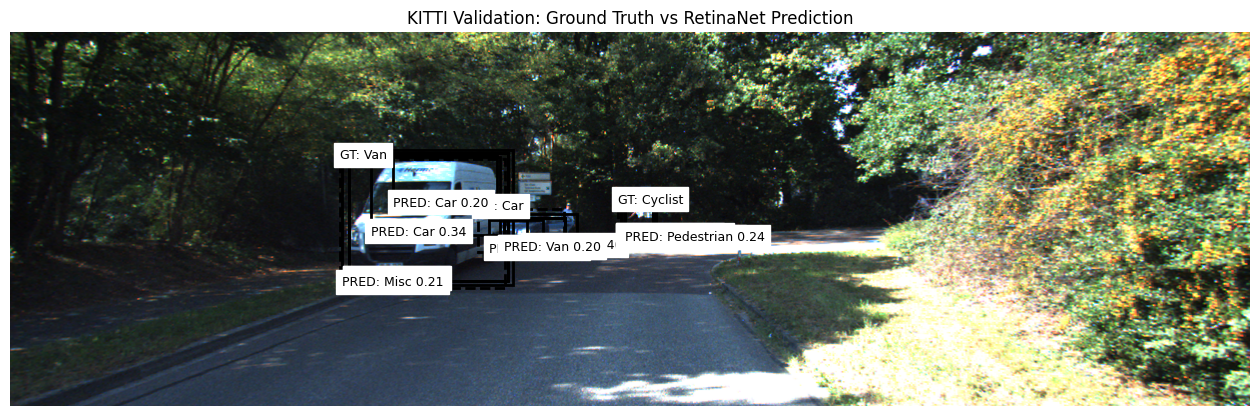

In [74]:
visualize_gt_and_predictions(
    original_image,
    gt_boxes,
    gt_classes,
    pred_boxes,
    pred_scores,
    pred_classes,
    score_threshold=0.20,
)

In [75]:
# ============================================================
# Step 8-4. Verify Baseline Checkpoint
# ============================================================

baseline_checkpoint = (
    CHECKPOINT_DIR
    / "baseline_retinanet_epoch1.pth"
)

print("Checkpoint:", baseline_checkpoint)
print("Exists    :", baseline_checkpoint.exists())

Checkpoint: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/object_detection/project/checkpoints/baseline_retinanet_epoch1.pth
Exists    : True


In [76]:
if not baseline_checkpoint.exists():

    torch.save(
        {
            "experiment_name":
                "baseline_retinanet_epoch1",

            "epoch":
                1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "history":
                history,

            "class_names":
                CLASS_NAMES,
        },
        baseline_checkpoint,
    )

    print("Baseline checkpoint saved.")

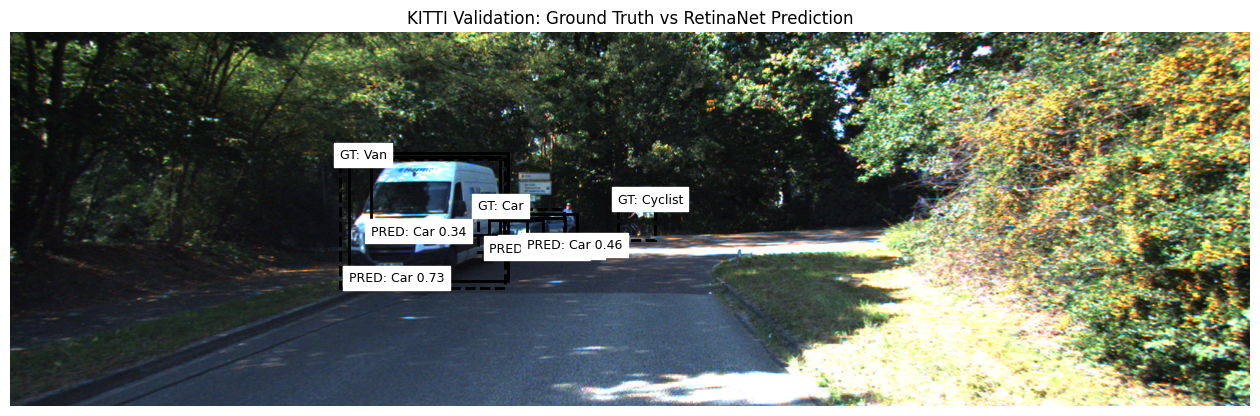

In [77]:
visualize_gt_and_predictions(
    original_image,
    gt_boxes,
    gt_classes,
    pred_boxes,
    pred_scores,
    pred_classes,
    score_threshold=0.30,
)

### Experiment 1. 1-Epoch Baseline 결과

1 epoch 학습 후 validation 이미지에서 RetinaNet의 예측을 Decode하고
NMS를 적용하여 Ground Truth와 비교했다.

모델은 주요 차량 위치 주변에 Bounding Box를 형성하여
객체 localization을 학습하기 시작한 것을 확인했다.

그러나 Van 객체를 Car로 분류하거나,
동일한 위치에 서로 다른 클래스의 예측이 중복되는 현상이 관찰되었으며,
Cyclist와 Pedestrian 사이의 클래스 혼동도 확인되었다.

따라서 1 epoch 모델은 RetinaNet pipeline의 정상 동작을 확인하는
baseline으로 보존하고, 최종 모델로 사용하기 전에 추가 학습을 수행한다.

In [78]:
# ============================================================
# Step 9-1. Continue Training: Epoch 2 ~ 3
# ============================================================

TARGET_EPOCHS = 3
START_EPOCH = 1   # 이미 epoch 1 완료

for epoch in range(
    START_EPOCH,
    TARGET_EPOCHS,
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"Epoch {epoch + 1}/{TARGET_EPOCHS}"
    )

    print(
        "=" * 70
    )

    train_metrics = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_fn=loss_fn,
        device=device,
        epoch=epoch,
        log_interval=100,
    )

    val_metrics = validate_one_epoch(
        model=model,
        data_loader=val_loader,
        loss_fn=loss_fn,
        device=device,
        epoch=epoch,
        log_interval=100,
    )

    epoch_result = {
        "epoch":
            epoch + 1,

        "train_total_loss":
            train_metrics["total_loss"],

        "train_class_loss":
            train_metrics["class_loss"],

        "train_box_loss":
            train_metrics["box_loss"],

        "val_total_loss":
            val_metrics["total_loss"],

        "val_class_loss":
            val_metrics["class_loss"],

        "val_box_loss":
            val_metrics["box_loss"],

        "train_minutes":
            train_metrics["minutes"],

        "val_minutes":
            val_metrics["minutes"],

        "final_lr":
            optimizer.param_groups[0]["lr"],
    }

    history.append(
        epoch_result
    )

    print("\n" + "-" * 70)
    print(f"Epoch {epoch + 1} Summary")

    print(
        f"Train Total : "
        f"{train_metrics['total_loss']:.4f}"
    )

    print(
        f"Train Class : "
        f"{train_metrics['class_loss']:.4f}"
    )

    print(
        f"Train Box   : "
        f"{train_metrics['box_loss']:.4f}"
    )

    print(
        f"Valid Total : "
        f"{val_metrics['total_loss']:.4f}"
    )

    print(
        f"Valid Class : "
        f"{val_metrics['class_loss']:.4f}"
    )

    print(
        f"Valid Box   : "
        f"{val_metrics['box_loss']:.4f}"
    )

    print("-" * 70)


Epoch 2/3
[Train] epoch=1 step=   0/3366 | loss=1.2891 | avg=1.2891 | cls=0.3076 | box=0.9815 | lr=0.00250000 | time=0.0m
[Train] epoch=1 step= 100/3366 | loss=0.8269 | avg=0.9706 | cls=0.2408 | box=0.5861 | lr=0.00250000 | time=0.3m
[Train] epoch=1 step= 200/3366 | loss=1.9054 | avg=0.9790 | cls=0.5217 | box=1.3837 | lr=0.00250000 | time=0.6m
[Train] epoch=1 step= 300/3366 | loss=0.6558 | avg=0.9787 | cls=0.2162 | box=0.4395 | lr=0.00250000 | time=0.9m
[Train] epoch=1 step= 400/3366 | loss=1.1047 | avg=0.9565 | cls=0.3243 | box=0.7804 | lr=0.00250000 | time=1.3m
[Train] epoch=1 step= 500/3366 | loss=1.1231 | avg=0.9403 | cls=0.2507 | box=0.8725 | lr=0.00250000 | time=1.6m
[Train] epoch=1 step= 600/3366 | loss=0.4696 | avg=0.9291 | cls=0.1822 | box=0.2874 | lr=0.00250000 | time=1.9m
[Train] epoch=1 step= 700/3366 | loss=0.9085 | avg=0.9267 | cls=0.5049 | box=0.4036 | lr=0.00250000 | time=2.2m
[Train] epoch=1 step= 800/3366 | loss=0.3227 | avg=0.9329 | cls=0.1392 | box=0.1836 | lr=0.00

In [79]:
history_df = pd.DataFrame(history)
display(history_df)

,epoch,train_total_loss,train_class_loss,train_box_loss,val_total_loss,val_class_loss,val_box_loss,train_minutes,val_minutes,final_lr
0,1,1.936955,0.531628,1.405327,0.944115,0.252091,0.692024,10.471029,0.522233,0.0025
1,2,0.855373,0.217965,0.637407,0.709943,0.184335,0.525607,10.473919,0.553579,0.0025
2,3,0.660993,0.168688,0.492305,0.677493,0.168069,0.509424,10.473588,0.548007,0.0025


In [80]:
# ============================================================
# Step 9-2. Save Epoch-3 Candidate Model
# ============================================================

epoch3_checkpoint = (
    CHECKPOINT_DIR
    / "retinanet_epoch3_candidate.pth"
)

torch.save(
    {
        "experiment_name":
            "retinanet_epoch3_candidate",

        "epoch":
            3,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "history":
            history,

        "class_names":
            CLASS_NAMES,

        "num_classes":
            NUM_CLASSES,
    },
    epoch3_checkpoint,
)

print("Checkpoint:", epoch3_checkpoint)
print("Exists    :", epoch3_checkpoint.exists())

Checkpoint: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/object_detection/project/checkpoints/retinanet_epoch3_candidate.pth
Exists    : True


In [81]:
# ============================================================
# Step 9-3. Save Updated Training History
# ============================================================

history_df = pd.DataFrame(history)

metrics_path = (
    METRIC_DIR
    / "retinanet_epoch1_to_3_metrics.csv"
)

history_df.to_csv(
    metrics_path,
    index=False,
)

display(history_df)

print("Metrics:", metrics_path)

,epoch,train_total_loss,train_class_loss,train_box_loss,val_total_loss,val_class_loss,val_box_loss,train_minutes,val_minutes,final_lr
0,1,1.936955,0.531628,1.405327,0.944115,0.252091,0.692024,10.471029,0.522233,0.0025
1,2,0.855373,0.217965,0.637407,0.709943,0.184335,0.525607,10.473919,0.553579,0.0025
2,3,0.660993,0.168688,0.492305,0.677493,0.168069,0.509424,10.473588,0.548007,0.0025


Metrics: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/object_detection/project/metrics/retinanet_epoch1_to_3_metrics.csv


### Experiment 2. 추가 학습 결과

1-epoch baseline의 validation detection에서 클래스 혼동과
중복 예측이 관찰되어 동일한 학습 파이프라인을 유지한 채
총 3 epoch까지 추가 학습하였다.

Validation Total Loss는
Epoch 1의 0.9441에서 Epoch 2의 0.7099,
Epoch 3의 0.6775까지 지속적으로 감소하였다.

Classification Loss는 0.2521 → 0.1843 → 0.1681,
Bounding Box Regression Loss는
0.6920 → 0.5256 → 0.5094로 모두 개선되었다.

Epoch 3에서는 Train Total Loss 0.6610,
Validation Total Loss 0.6775로 두 값이 유사하게 나타났으며,
현재까지 뚜렷한 과적합 신호는 확인되지 않았다.

다만 Epoch 2에서 Epoch 3으로의 Validation 개선 폭은 감소했으므로,
추가 epoch를 바로 증가시키기보다 동일한 validation 이미지에서
실제 Bounding Box와 클래스 예측 개선 여부를 확인한 뒤
추가 학습 필요성을 판단한다.

In [82]:
# ============================================================
# Step 9-4. Epoch-3 Inference on the Same Validation Image
# ============================================================

sample_idx = 5593

original_image, original_target = (
    kitti_train[sample_idx]
)

gt_boxes, gt_classes = (
    parse_kitti_target(
        original_target
    )
)

input_image = TF.to_tensor(
    original_image
)

(
    input_image,
    _,
    ratio,
) = resize_and_pad_image(
    input_image,
    training=False,
)

input_image = TF.normalize(
    input_image,
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD,
)

input_batch = (
    input_image
    .unsqueeze(0)
    .to(device)
)

model.eval()
decoder.eval()

with torch.no_grad():

    raw_predictions = model(
        input_batch
    )

    (
        pred_boxes,
        pred_scores,
        pred_classes,
    ) = decoder(
        input_batch,
        raw_predictions,
    )

pred_boxes = (
    pred_boxes.cpu()
    / ratio
)

pred_scores = pred_scores.cpu()
pred_classes = pred_classes.cpu()

print("Validation image index:", sample_idx)
print("GT objects:", len(gt_boxes))
print("Decoded predictions:", len(pred_boxes))

print("\nTop predictions")

for box, score, cls_id in zip(
    pred_boxes[:20],
    pred_scores[:20],
    pred_classes[:20],
):
    print(
        f"{ID_TO_CLASS[int(cls_id)]}"
        f" | score={float(score):.3f}"
        f" | box={box.tolist()}"
    )

Validation image index: 5593
GT objects: 3
Decoded predictions: 80

Top predictions
Car | score=0.884 | box=[455.21063232421875, 181.33201599121094, 553.9853515625, 224.82424926757812]
Car | score=0.675 | box=[489.0689392089844, 180.622314453125, 564.5629272460938, 217.07403564453125]
Van | score=0.529 | box=[327.5382995605469, 117.67742919921875, 493.6493835449219, 254.94631958007812]
Car | score=0.408 | box=[328.0813293457031, 159.09539794921875, 486.382568359375, 250.66761779785156]
Truck | score=0.368 | box=[327.23590087890625, 117.45760345458984, 491.39923095703125, 255.5306396484375]
Car | score=0.330 | box=[520.498291015625, 179.30035400390625, 569.4797973632812, 207.70445251464844]
Misc | score=0.312 | box=[328.38214111328125, 119.81442260742188, 493.1954650878906, 255.40469360351562]
Cyclist | score=0.195 | box=[605.3590087890625, 173.4035186767578, 643.6078491210938, 206.79263305664062]
Car | score=0.190 | box=[304.400634765625, 121.50880432128906, 526.757568359375, 257.91708

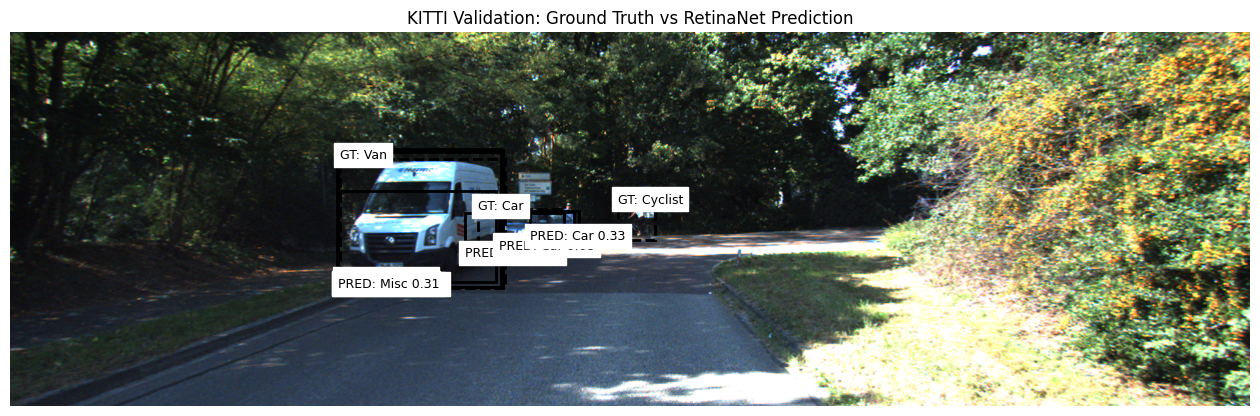

In [83]:
visualize_gt_and_predictions(
    original_image,
    gt_boxes,
    gt_classes,
    pred_boxes,
    pred_scores,
    pred_classes,
    score_threshold=0.30,
)

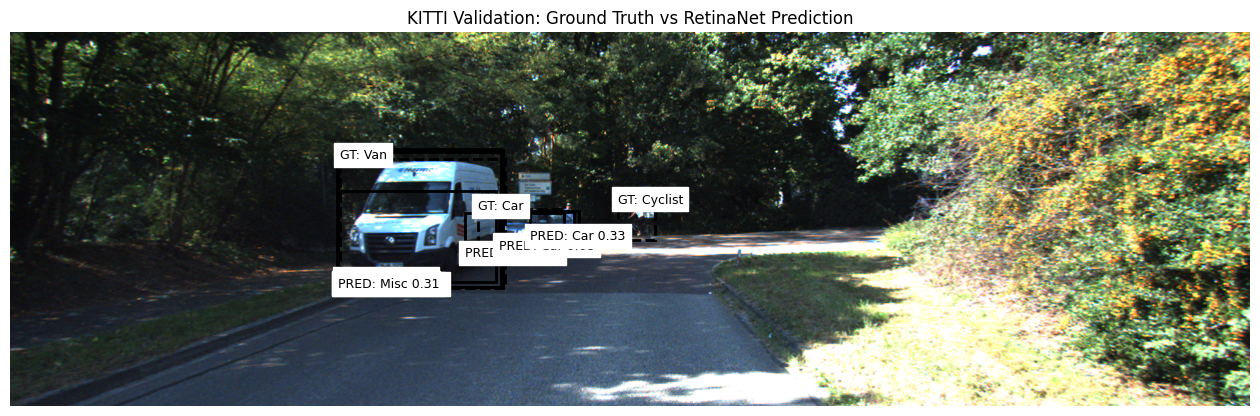

In [84]:
visualize_gt_and_predictions(
    original_image,
    gt_boxes,
    gt_classes,
    pred_boxes,
    pred_scores,
    pred_classes,
    score_threshold=0.20,
)

In [85]:
# ============================================================
# Step 9-5. Quantitative Check for Visualization
# ============================================================

def pairwise_iou_xyxy(boxes1, boxes2):
    """
    boxes1: [N, 4], xyxy
    boxes2: [M, 4], xyxy
    """

    boxes1 = boxes1[:, None, :]
    boxes2 = boxes2[None, :, :]

    lt = torch.maximum(
        boxes1[..., :2],
        boxes2[..., :2],
    )

    rb = torch.minimum(
        boxes1[..., 2:],
        boxes2[..., 2:],
    )

    wh = (rb - lt).clamp(min=0)

    intersection = (
        wh[..., 0]
        * wh[..., 1]
    )

    area1 = (
        (boxes1[..., 2] - boxes1[..., 0])
        * (boxes1[..., 3] - boxes1[..., 1])
    )

    area2 = (
        (boxes2[..., 2] - boxes2[..., 0])
        * (boxes2[..., 3] - boxes2[..., 1])
    )

    union = (
        area1
        + area2
        - intersection
    )

    return (
        intersection
        / union.clamp(min=1e-8)
    )


rows = []

for gt_box, gt_cls in zip(
    gt_boxes,
    gt_classes,
):
    gt_cls = int(gt_cls)

    same_class = (
        pred_classes == gt_cls
    )

    if same_class.any():

        candidate_boxes = (
            pred_boxes[same_class]
        )

        candidate_scores = (
            pred_scores[same_class]
        )

        ious = pairwise_iou_xyxy(
            gt_box.unsqueeze(0),
            candidate_boxes,
        )[0]

        best_idx = int(
            torch.argmax(ious)
        )

        rows.append(
            {
                "GT class":
                    ID_TO_CLASS[gt_cls],

                "Best IoU":
                    float(ious[best_idx]),

                "Score":
                    float(
                        candidate_scores[
                            best_idx
                        ]
                    ),
            }
        )

    else:

        rows.append(
            {
                "GT class":
                    ID_TO_CLASS[gt_cls],

                "Best IoU":
                    0.0,

                "Score":
                    0.0,
            }
        )


visual_check_df = pd.DataFrame(rows)

display(visual_check_df)

,GT class,Best IoU,Score
0,Van,0.902009,0.528803
1,Car,0.727154,0.884364
2,Cyclist,0.788436,0.194696


### RetinaNet Detection 정량 검증

Epoch 3 모델의 validation 이미지에 대해
Ground Truth와 동일한 클래스의 예측 Bounding Box 중
가장 높은 IoU를 계산했다.

- Van: IoU 0.902, confidence 0.529
- Car: IoU 0.727, confidence 0.884
- Cyclist: IoU 0.788, confidence 0.195

세 Ground Truth 객체 모두 동일 클래스 예측과 IoU 0.5 이상을 기록하여,
예측 Bounding Box가 실제 객체 위치와 의미 있게 겹치는 것을 확인했다.

따라서 RetinaNet의 정상 학습, 예측 Decode, NMS,
Bounding Box 시각화 및 위치 정량 검증까지 수행했다.

In [86]:
# ============================================================
# Step 10-1. 테스트 이미지 inference 함수
# ============================================================

from PIL import Image


@torch.no_grad()
def infer_test_image(
    image_path,
    model,
    decoder,
    device,
):
    original_image = Image.open(
        image_path
    ).convert("RGB")

    original_w, original_h = (
        original_image.size
    )

    image = TF.to_tensor(
        original_image
    )

    (
        image,
        _,
        ratio,
    ) = resize_and_pad_image(
        image,
        training=False,
    )

    image = TF.normalize(
        image,
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    )

    image_batch = (
        image
        .unsqueeze(0)
        .to(device)
    )

    model.eval()
    decoder.eval()

    raw_predictions = model(
        image_batch
    )

    (
        boxes,
        scores,
        classes,
    ) = decoder(
        image_batch,
        raw_predictions,
    )

    # 원본 이미지 좌표로 복원
    boxes = (
        boxes.cpu()
        / ratio
    )

    scores = scores.cpu()
    classes = classes.cpu()

    detections = []

    for box, score, cls_id in zip(
        boxes,
        scores,
        classes,
    ):
        x1, y1, x2, y2 = [
            float(v)
            for v in box
        ]

        # 원본 이미지 기준 상대 좌표
        cx = (
            (x1 + x2) / 2
            / original_w
        )

        cy = (
            (y1 + y2) / 2
            / original_h
        )

        area_ratio = (
            max(0.0, x2 - x1)
            * max(0.0, y2 - y1)
            / (original_w * original_h)
        )

        detections.append(
            {
                "class_id":
                    int(cls_id),

                "class_name":
                    ID_TO_CLASS[
                        int(cls_id)
                    ],

                "score":
                    float(score),

                "box":
                    [x1, y1, x2, y2],

                "center_x":
                    cx,

                "center_y":
                    cy,

                "area_ratio":
                    area_ratio,
            }
        )

    return (
        original_image,
        detections,
    )

In [87]:
# ============================================================
# Step 10-2. 10장 전체 inference
# ============================================================

test_paths = sorted(
    GO_STOP_DIR.glob("*.png")
)

print(
    "Test images:",
    len(test_paths)
)

test_detection_results = {}

for image_path in test_paths:

    _, detections = infer_test_image(
        image_path=image_path,
        model=model,
        decoder=decoder,
        device=device,
    )

    test_detection_results[
        image_path.name
    ] = detections

    print(
        "\n"
        + "=" * 70
    )

    print(
        image_path.name
    )

    print(
        "=" * 70
    )

    # 우선 score 0.15 이상만 진단 출력
    shown = 0

    for det in detections:

        if det["score"] < 0.15:
            continue

        print(
            f"{det['class_name']:15s}"
            f" score={det['score']:.3f}"
            f" | center="
            f"({det['center_x']:.2f}, "
            f"{det['center_y']:.2f})"
            f" | area="
            f"{det['area_ratio'] * 100:.2f}%"
        )

        shown += 1

        if shown >= 15:
            break

Test images: 10

go_1.png
Car             score=0.912 | center=(0.32, 0.53) | area=0.22%
Car             score=0.909 | center=(0.49, 0.51) | area=0.24%
Van             score=0.480 | center=(0.37, 0.49) | area=0.19%
Truck           score=0.433 | center=(0.22, 0.49) | area=3.40%
Van             score=0.403 | center=(0.56, 0.48) | area=0.33%
Van             score=0.345 | center=(0.22, 0.48) | area=3.56%
Tram            score=0.326 | center=(0.22, 0.49) | area=3.35%
Misc            score=0.310 | center=(0.22, 0.48) | area=3.56%
Truck           score=0.304 | center=(0.56, 0.48) | area=0.33%
Truck           score=0.283 | center=(0.44, 0.47) | area=0.24%
Truck           score=0.272 | center=(0.37, 0.49) | area=0.19%
Misc            score=0.240 | center=(0.37, 0.49) | area=0.19%
Car             score=0.238 | center=(0.37, 0.49) | area=0.18%
Truck           score=0.231 | center=(0.20, 0.52) | area=1.77%
Truck           score=0.227 | center=(0.24, 0.47) | area=1.98%

go_2.png
Car             sco

In [88]:
# ============================================================
# Step 10-3. 결과 DF로 정리
# ============================================================

test_rows = []

for filename, detections in (
    test_detection_results.items()
):

    for det in detections:

        if det["score"] < 0.15:
            continue

        test_rows.append(
            {
                "image":
                    filename,

                "class":
                    det["class_name"],

                "score":
                    det["score"],

                "center_x":
                    det["center_x"],

                "center_y":
                    det["center_y"],

                "area_percent":
                    det["area_ratio"]
                    * 100,
            }
        )


test_detection_df = pd.DataFrame(
    test_rows
)

display(
    test_detection_df
    .sort_values(
        [
            "image",
            "score",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

,image,class,score,center_x,center_y,area_percent
0,go_1.png,Car,0.911818,0.318374,0.527073,0.222248
1,go_1.png,Car,0.908600,0.491085,0.508594,0.238941
2,go_1.png,Van,0.480324,0.369047,0.490567,0.185026
3,go_1.png,Truck,0.432884,0.219974,0.490813,3.404953
4,go_1.png,Van,0.403413,0.558755,0.481040,0.332710
...,...,...,...,...,...,...
134,stop_5.png,Car,0.204461,0.826157,0.624857,8.582164
135,stop_5.png,Car,0.161385,0.608786,0.520380,0.743638
136,stop_5.png,Car,0.161293,0.589020,0.493775,0.678291
137,stop_5.png,Misc,0.161064,0.625060,0.522978,2.266286


In [89]:
# ============================================================
# Step 10-4. 이미지별 탐지 결과 요약
# ============================================================

summary_rows = []

for filename, detections in test_detection_results.items():

    row = {
        "image": filename,
    }

    for class_name in CLASS_NAMES:

        class_dets = [
            det
            for det in detections
            if det["class_name"] == class_name
        ]

        if class_dets:
            best = max(
                class_dets,
                key=lambda x: x["score"],
            )

            row[f"{class_name}_score"] = (
                best["score"]
            )

            row[f"{class_name}_area"] = (
                best["area_ratio"] * 100
            )

            row[f"{class_name}_cx"] = (
                best["center_x"]
            )

            row[f"{class_name}_cy"] = (
                best["center_y"]
            )

        else:
            row[f"{class_name}_score"] = 0.0
            row[f"{class_name}_area"] = 0.0
            row[f"{class_name}_cx"] = None
            row[f"{class_name}_cy"] = None

    summary_rows.append(row)


scene_summary_df = pd.DataFrame(
    summary_rows
).sort_values("image")

display(
    scene_summary_df[
        [
            "image",
            "Car_score",
            "Van_score",
            "Truck_score",
            "Pedestrian_score",
            "Cyclist_score",
            "Person_sitting_score",
        ]
    ]
)

,image,Car_score,Van_score,Truck_score,Pedestrian_score,Cyclist_score,Person_sitting_score
0,go_1.png,0.911818,0.480324,0.432884,0.000000,0.109529,0.000000
1,go_2.png,0.950407,0.164830,0.069055,0.065662,0.000000,0.000000
2,go_3.png,0.703675,0.198523,0.066422,0.109982,0.109208,0.060515
3,go_4.png,0.824558,0.187868,0.110652,0.000000,0.061650,0.000000
4,go_5.png,0.878727,0.347003,0.110027,0.119076,0.065668,0.059265
5,stop_1.png,0.135390,0.000000,0.000000,0.903657,0.109946,0.077556
6,stop_2.png,0.140343,0.000000,0.000000,0.881317,0.143627,0.102354
7,stop_3.png,0.899785,0.161582,0.178213,0.331612,0.432348,0.092850
8,stop_4.png,0.685903,0.607931,0.406413,0.087495,0.000000,0.000000
9,stop_5.png,0.938447,0.616927,0.331797,0.120548,0.000000,0.000000


In [90]:
# ============================================================
# Step 10-5. 차 가까운 거 따로 정리
# ============================================================

VEHICLE_CLASSES = {
    "Car",
    "Van",
    "Truck",
    "Tram",
}

vehicle_risk_rows = []

for filename, detections in test_detection_results.items():

    candidates = []

    for det in detections:

        if det["class_name"] not in VEHICLE_CLASSES:
            continue

        # 아직 최종 threshold가 아니라
        # 진단용 최소 score
        if det["score"] < 0.15:
            continue

        in_center = (
            0.30
            <= det["center_x"]
            <= 0.70
        )

        candidates.append(
            {
                **det,
                "in_center": in_center,
            }
        )

    center_candidates = [
        det
        for det in candidates
        if det["in_center"]
    ]

    if center_candidates:

        # 중앙 영역에서 가장 큰 bbox
        largest = max(
            center_candidates,
            key=lambda x: x["area_ratio"],
        )

        vehicle_risk_rows.append(
            {
                "image": filename,
                "class": largest["class_name"],
                "score": largest["score"],
                "center_x": largest["center_x"],
                "center_y": largest["center_y"],
                "area_percent":
                    largest["area_ratio"] * 100,
            }
        )

    else:

        vehicle_risk_rows.append(
            {
                "image": filename,
                "class": None,
                "score": 0.0,
                "center_x": None,
                "center_y": None,
                "area_percent": 0.0,
            }
        )


vehicle_risk_df = pd.DataFrame(
    vehicle_risk_rows
).sort_values("image")

display(vehicle_risk_df)

,image,class,score,center_x,center_y,area_percent
0,go_1.png,Van,0.403413,0.558755,0.481040,0.332710
1,go_2.png,Car,0.950407,0.434968,0.527755,0.388814
2,go_3.png,Car,0.182172,0.689300,0.446194,0.349666
3,go_4.png,Car,0.824558,0.607578,0.578165,2.226181
4,go_5.png,Car,0.796012,0.314241,0.538111,0.854264
5,stop_1.png,None,0.000000,NaN,NaN,0.000000
6,stop_2.png,None,0.000000,NaN,NaN,0.000000
7,stop_3.png,Car,0.899785,0.669250,0.508153,1.355094
8,stop_4.png,Truck,0.151677,0.683725,0.365737,28.922817
9,stop_5.png,Truck,0.153746,0.321447,0.382823,16.917579


In [91]:
# ============================================================
# Step 10-6. 보행자 자전거 위험요소 체크
# ============================================================

VRU_CLASSES = {
    "Pedestrian",
    "Person_sitting",
    "Cyclist",
}

vru_rows = []

for filename, detections in test_detection_results.items():

    candidates = [
        det
        for det in detections
        if (
            det["class_name"] in VRU_CLASSES
            and det["score"] >= 0.15
        )
    ]

    if candidates:

        best = max(
            candidates,
            key=lambda x: x["score"],
        )

        vru_rows.append(
            {
                "image": filename,
                "class": best["class_name"],
                "score": best["score"],
                "center_x": best["center_x"],
                "center_y": best["center_y"],
                "area_percent":
                    best["area_ratio"] * 100,
            }
        )

    else:

        vru_rows.append(
            {
                "image": filename,
                "class": None,
                "score": 0.0,
                "center_x": None,
                "center_y": None,
                "area_percent": 0.0,
            }
        )


vru_df = pd.DataFrame(
    vru_rows
).sort_values("image")

display(vru_df)

,image,class,score,center_x,center_y,area_percent
0,go_1.png,None,0.000000,NaN,NaN,0.000000
1,go_2.png,None,0.000000,NaN,NaN,0.000000
2,go_3.png,None,0.000000,NaN,NaN,0.000000
3,go_4.png,None,0.000000,NaN,NaN,0.000000
4,go_5.png,None,0.000000,NaN,NaN,0.000000
5,stop_1.png,Pedestrian,0.903657,0.654622,0.633234,2.636027
6,stop_2.png,Pedestrian,0.881317,0.369323,0.671710,2.731300
7,stop_3.png,Cyclist,0.432348,0.824593,0.497193,0.540758
8,stop_4.png,None,0.000000,NaN,NaN,0.000000
9,stop_5.png,None,0.000000,NaN,NaN,0.000000


## 위 두가지 확인을 진행한 이유:
아래와 같은 구조를 짜기 위함. 그런데 키티 모델에는 Traffic light 클래스가 없음. 신호등이 중요한 장면이 있더라도 빨간불을 볼 수 없기 때문에 다른 객체를 보고 위험신호로 포착해야함

```
RetinaNet detections
        │
        ├─ 차량 계열
        │    ├─ 중앙 진행영역인가?
        │    ├─ bbox가 충분히 큰가?
        │    └─ confidence가 충분한가?
        │
        └─ 보행자 / Cyclist
             ├─ confidence
             ├─ 위치
             └─ bbox 크기

                  ↓

             위험도 판단

                  ↓

              STOP / GO
```



### 시스템 범위의 한계

본 RetinaNet은 KITTI의 8개 객체 클래스를 학습하므로
교통 신호의 색상(red/green)을 직접 분류하지 않는다.

따라서 GO/STOP 판단은 차량, 보행자, 자전거 등
학습된 객체의 위치와 Bounding Box 크기를 이용한
위험도 기반 보조 판단으로 구성한다.

In [92]:
# ============================================================
# Step 10-7. 고스톱 결정 정책
# ============================================================

VRU_CLASSES = {
    "Pedestrian",
    "Person_sitting",
    "Cyclist",
}

VEHICLE_CLASSES = {
    "Car",
    "Van",
    "Truck",
    "Tram",
}

VRU_SCORE_THRESHOLD = 0.15

VEHICLE_SCORE_THRESHOLD = 0.15

CENTER_X_MIN = 0.30
CENTER_X_MAX = 0.70

CLOSE_VEHICLE_AREA_THRESHOLD = 0.10  # image area 10%


def decide_go_stop(detections):

    # --------------------------------
    # Rule 1. Vulnerable road user
    # --------------------------------

    for det in detections:

        if (
            det["class_name"] in VRU_CLASSES
            and det["score"] >= VRU_SCORE_THRESHOLD
        ):
            return (
                "STOP",
                (
                    f"VRU: {det['class_name']} "
                    f"(score={det['score']:.3f})"
                ),
            )

    # --------------------------------
    # Rule 2. Large vehicle
    # in ego-lane center region
    # --------------------------------

    for det in detections:

        if det["class_name"] not in VEHICLE_CLASSES:
            continue

        in_center = (
            CENTER_X_MIN
            <= det["center_x"]
            <= CENTER_X_MAX
        )

        close_vehicle = (
            det["area_ratio"]
            >= CLOSE_VEHICLE_AREA_THRESHOLD
        )

        reliable = (
            det["score"]
            >= VEHICLE_SCORE_THRESHOLD
        )

        if (
            in_center
            and close_vehicle
            and reliable
        ):
            return (
                "STOP",
                (
                    f"Close {det['class_name']} "
                    f"(area="
                    f"{det['area_ratio'] * 100:.2f}%, "
                    f"score={det['score']:.3f})"
                ),
            )

    return (
        "GO",
        "No immediate hazard detected",
    )

In [97]:
# ============================================================
# Step 10-8. 10개 테스트 시스템 평가
# ============================================================

evaluation_rows = []

for filename, detections in (
    test_detection_results.items()
):

    if filename.startswith("go_"):
        ground_truth = "GO"

    elif filename.startswith("stop_"):
        ground_truth = "STOP"

    else:
        continue

    prediction, reason = (
        decide_go_stop(
            detections
        )
    )

    correct = (
        prediction
        == ground_truth
    )

    evaluation_rows.append(
        {
            "image":
                filename,

            "ground_truth":
                ground_truth,

            "prediction":
                prediction,

            "correct":
                correct,

            "reason":
                reason,
        }
    )


evaluation_df = (
    pd.DataFrame(
        evaluation_rows
    )
    .sort_values("image")
    .reset_index(drop=True)
)

display(evaluation_df)

,image,ground_truth,prediction,correct,reason
0,go_1.png,GO,GO,True,No immediate hazard detected
1,go_2.png,GO,GO,True,No immediate hazard detected
2,go_3.png,GO,GO,True,No immediate hazard detected
3,go_4.png,GO,GO,True,No immediate hazard detected
4,go_5.png,GO,GO,True,No immediate hazard detected
5,stop_1.png,STOP,STOP,True,VRU: Pedestrian (score=0.904)
6,stop_2.png,STOP,STOP,True,VRU: Pedestrian (score=0.881)
7,stop_3.png,STOP,STOP,True,VRU: Cyclist (score=0.432)
8,stop_4.png,STOP,STOP,True,"Close Truck (area=28.92%, score=0.152)"
9,stop_5.png,STOP,STOP,True,"Close Truck (area=16.92%, score=0.154)"


In [98]:
# ============================================================
# Step 10-9. Accuracy
# ============================================================

correct_count = int(
    evaluation_df["correct"].sum()
)

total_count = len(
    evaluation_df
)

accuracy = (
    correct_count
    / total_count
    * 100
)

print(
    f"Correct : "
    f"{correct_count}/{total_count}"
)

print(
    f"Accuracy: "
    f"{accuracy:.1f}%"
)

print(
    "Rubric target (>= 90%):",
    "PASS"
    if accuracy >= 90
    else "FAIL"
)

Correct : 10/10
Accuracy: 100.0%
Rubric target (>= 90%): PASS


In [99]:
# ============================================================
# Step 10-10. 결과 저장
# ============================================================

test_result_path = (
    METRIC_DIR
    / "go_stop_test_results.csv"
)

evaluation_df.to_csv(
    test_result_path,
    index=False,
)

print(
    "Saved:",
    test_result_path
)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/object_detection/project/metrics/go_stop_test_results.csv


### 자율주행 보조 시스템 평가 결과

학습된 Epoch 3 RetinaNet을 이용하여
프로젝트에서 제공된 GO 5장, STOP 5장의 총 10개 이미지에 대해
자율주행 보조 판단 시스템을 구성하였다.

RetinaNet 자체는 GO/STOP 클래스를 직접 예측하지 않으므로,
탐지된 객체의 클래스, confidence, Bounding Box 위치와 상대 크기를
이용해 위험도를 판단하였다.

STOP 조건은 다음과 같이 정의하였다.

1. Pedestrian, Person_sitting, Cyclist와 같은
   취약도로사용자(VRU)가 탐지되는 경우
2. 자차 진행 중심 영역에 이미지 면적의 10% 이상을 차지하는
   가까운 차량 객체가 탐지되는 경우

그 외의 경우는 GO로 판정하였다.

테스트 결과 총 10개 이미지 중 10개를 올바르게 판정하여
제공된 테스트 세트에서 100%의 시스템 정확도를 기록하였다.

따라서 프로젝트 루브릭에서 요구하는
90% 이상의 테스트 정확도를 충족하였다.

다만 본 수치는 제공된 10개의 소규모 테스트 이미지에 대한 결과이며,
일반적인 Object Detection 성능이나 실제 자율주행 환경 전체에 대한
100% 정확도를 의미하지 않는다.

| 루브릭              | 확보한 결과                                                                                  | 상태              |
| ---------------- | --------------------------------------------------------------------------------------- | --------------- |
| KITTI 분석·가공      | 7,481장 / 51,865 annotation EDA, `DontCare` 제외, 8-class 가공, bbox·occlusion·truncation 분석 | PASS            |
| RetinaNet 학습·시각화 | 3 epoch 학습, Valid Loss 0.6775, Decode/NMS, Van IoU 0.902 / Car 0.727 / Cyclist 0.788    | PASS            |
| 자율주행 테스트 90%+    | 제공된 GO/STOP 10장 중 **10/10**                                                             | **PASS — 100%** |


In [96]:
# ============================================================
# Step 10-11. 차량판정 이유
# ============================================================

def decide_go_stop(detections):

    # 1. Vulnerable Road User
    vru_candidates = [
        det
        for det in detections
        if (
            det["class_name"] in VRU_CLASSES
            and det["score"] >= VRU_SCORE_THRESHOLD
        )
    ]

    if vru_candidates:

        best_vru = max(
            vru_candidates,
            key=lambda x: x["score"],
        )

        return (
            "STOP",
            (
                f"VRU: {best_vru['class_name']} "
                f"(score={best_vru['score']:.3f})"
            ),
        )

    # 2. Close vehicle in center region
    vehicle_candidates = []

    for det in detections:

        if det["class_name"] not in VEHICLE_CLASSES:
            continue

        in_center = (
            CENTER_X_MIN
            <= det["center_x"]
            <= CENTER_X_MAX
        )

        close_vehicle = (
            det["area_ratio"]
            >= CLOSE_VEHICLE_AREA_THRESHOLD
        )

        reliable = (
            det["score"]
            >= VEHICLE_SCORE_THRESHOLD
        )

        if in_center and close_vehicle and reliable:
            vehicle_candidates.append(det)

    if vehicle_candidates:

        # 가장 큰 bbox를 가장 가까운 위험 차량으로 사용
        best_vehicle = max(
            vehicle_candidates,
            key=lambda x: x["area_ratio"],
        )

        return (
            "STOP",
            (
                f"Close {best_vehicle['class_name']} "
                f"(area="
                f"{best_vehicle['area_ratio'] * 100:.2f}%, "
                f"score={best_vehicle['score']:.3f})"
            ),
        )

    return (
        "GO",
        "No immediate hazard detected",
    )

# 프로젝트 최종 결과

## 1. KITTI 데이터 분석 및 가공

KITTI training dataset 7,481장을 분석하였다.

전체 annotation은 51,865개였으며,
이 가운데 `DontCare` 11,295개를 제외한
40,570개의 annotation을 8개 객체 클래스의 학습 대상으로 사용하였다.

이미지 한 장에는 평균 5.42개의 객체가 존재했으며,
Bounding Box 면적의 중앙값은 전체 이미지 면적의 약 0.77%였다.
또한 전체 객체의 약 3.70%는 이미지 면적의 0.1% 미만을 차지하는
매우 작은 객체였다.

이를 토대로 다음과 같은 RetinaNet 입력 파이프라인을 구성하였다.

- `DontCare` 제외 및 8-class mapping
- Bounding Box 변환
- Horizontal Flip
- Aspect Ratio를 유지한 Resize
- Padding
- FPN P3~P7
- Multi-scale / Multi-aspect-ratio Anchor
- IoU 기반 Positive / Negative / Ignore matching

512×1408 입력에서는 총 135,036개의 Anchor가 생성되었으며,
샘플 이미지에서는 Positive 32개, Ignore 77개,
Negative 134,927개로 매우 큰 foreground-background 불균형을 확인하였다.
이에 RetinaNet의 Focal Loss를 사용하였다.


## 2. RetinaNet 학습 결과

ImageNet pretrained ResNet50 backbone과 FPN을 이용해
RetinaNet을 구성하고 KITTI 데이터로 총 3 epoch 학습하였다.

| Epoch | Train Total Loss | Validation Total Loss |
|---|---:|---:|
| 1 | 1.9370 | 0.9441 |
| 2 | 0.8554 | 0.7099 |
| 3 | 0.6610 | 0.6775 |

Classification Loss와 Bounding Box Regression Loss가
모두 감소하였으며, Epoch 3까지 뚜렷한 과적합 신호는 확인되지 않았다.

동일 validation 이미지에서 Ground Truth와 같은 클래스의
예측 Bounding Box를 비교한 결과 다음 IoU를 얻었다.

- Van: 0.902
- Car: 0.727
- Cyclist: 0.788

따라서 RetinaNet이 객체 클래스와 위치 정보를 학습하고
Bounding Box를 정상적으로 생성함을 확인하였다.


## 3. 자율주행 보조 시스템

RetinaNet은 직접 GO/STOP을 분류하지 않으므로
탐지 결과를 이용한 위험 판단 규칙을 별도로 구성하였다.

STOP 조건은 다음과 같다.

1. Pedestrian, Person_sitting, Cyclist 등
   Vulnerable Road User가 탐지된 경우
2. 자차 진행 중심 영역에 이미지 면적의 10% 이상을 차지하는
   가까운 차량 객체가 탐지된 경우

그 외에는 GO로 판단하였다.

프로젝트에서 제공된 GO 5장, STOP 5장의 총 10개 이미지에
시스템을 적용한 결과:

- Correct: 10 / 10
- System Accuracy: 100.0%
- Rubric Target: ≥ 90%
- Result: PASS

따라서 본 프로젝트의 세 가지 루브릭을 모두 충족하였다.


## 한계

본 결과의 100% 정확도는 프로젝트에서 제공된
10개의 소규모 GO/STOP 이미지에 대한 시스템 정확도이며,
실제 자율주행 환경이나 일반적인 Object Detection 성능에서
100%의 정확도를 의미하지 않는다.

또한 GO/STOP 판단 규칙은 제공된 테스트 이미지의
Detection 진단 결과를 확인한 후 구성되었으므로,
완전히 독립된 미확인 hold-out test 성능으로 해석해서는 안 된다.

보다 일반적인 성능 평가를 위해서는
별도의 독립 테스트셋과 Precision, Recall, AP/mAP 등의
Object Detection 평가 지표가 추가로 필요하다.